# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of four synthetic data generation models:
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


## Data Loading and Setup


In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load data
data = pd.read_csv(
    'C:/Users/Gopi.Battineni/OneDrive - University of Limerick/Desktop/FORGE/Synthetic-data_Audit/Datasets/Banking.csv'
)

# Take first 10,000 rows
data = data.head(10000).reset_index(drop=True)

print(f"Sampled data shape: {data.shape}")
print(f"Columns: {list(data.columns)}")

Sampled data shape: (10000, 16)
Columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [3]:
# Make a copy to avoid chained assignment issues
data = data.copy()

# Normalize text columns once
text_cols = ['job', 'education', 'marital', 'default', 'housing', 'loan', 'contact']
data[text_cols] = data[text_cols].apply(lambda x: x.astype(str).str.lower())

# ---------------------------
# Remove 'unknown' categories
# ---------------------------
data = data[~data['marital'].eq('unknown')]
data = data[~data['job'].eq('unknown')]
data = data[~data['education'].eq('unknown')]

binary_cols = ['default', 'housing', 'loan', 'contact']
data = data[~data[binary_cols].eq('unknown').any(axis=1)]

# ---------------------------
# Convert to categorical
# ---------------------------
cat_cols = ['job', 'education', 'marital']
for col in cat_cols:
    data[col] = data[col].astype('category')
    print(f"{col} categories:", data[col].cat.categories)

# ---------------------------
# Binary encoding
# ---------------------------
binary_map = {
    'no': 0,
    'yes': 1,
    'cellular': 0,
    'telephone': 1
}

data[binary_cols] = data[binary_cols].replace(binary_map)

# Convert binary columns to int
data[binary_cols] = data[binary_cols].astype(int)

# Verify
print("\nBinary column unique values:")
for col in binary_cols:
    print(col, sorted(data[col].unique()))

job categories: Index(['admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management',
       'retired', 'self-employed', 'services', 'student', 'technician',
       'unemployed'],
      dtype='object')
education categories: Index(['basic.4y', 'basic.6y', 'basic.9y', 'high.school', 'illiterate',
       'professional.course', 'university.degree'],
      dtype='object')
marital categories: Index(['divorced', 'married', 'single'], dtype='object')

Binary column unique values:
default [0]
housing [0, 1]
loan [0, 1]
contact [0, 1]


## Helper Functions

Shared functions for evaluation metrics across all models.


In [4]:
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")

In [5]:
data['y'] = data['y'].map({'no':0, 'yes':1})
data['y'].value_counts()

y
0    6383
1     922
Name: count, dtype: int64

In [6]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

def bivariate_quality_banking(real_df, synth_df, target='y'):
    """Compute bivariate quality metrics for cancer data."""
    num_cols = [c for c in real_df.columns if c != target]
    
    # Min-Max scaling on numeric columns
    scaler = MinMaxScaler()
    
    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()
    
    # Fit on real, transform both real and synthetic
    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])
    
    results_corr = []
    results_target = []

    # Numeric-to-numeric: Δ-correlation
    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            'var_a': a,
            'var_b': b,
            'delta_corr': abs(r_corr - s_corr)
        })
    
    # Numeric-to-target: Δ-Wasserstein between classes
    for col in num_cols:
        r_groups = [g[col].values for _, g in real_scaled.groupby(target)]
        s_groups = [g[col].values for _, g in synth_scaled.groupby(target)]
        
        if len(r_groups) == 2 and len(s_groups) == 2:
            d_real = stats.wasserstein_distance(*r_groups)
            d_synth = stats.wasserstein_distance(*s_groups)
            results_target.append({
                "feature": col,
                "delta_wasserstein": abs(d_real - d_synth)
            })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = pd.DataFrame(results_target).sort_values("delta_wasserstein", ascending=False)
    
    return corr_df, target_df

## Generating synthetic data

In [7]:
from sdv.metadata import SingleTableMetadata

# Columns that are binary but stored as int
binary_cols = ['default', 'housing', 'loan', 'contact', 'y']

# TEMPORARY cast — required so detect_from_dataframe does not crash
data[binary_cols] = data[binary_cols].astype('category')

# Detect metadata safely
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)

# Explicitly enforce categorical type (OPTION 1)
for col in binary_cols:
    metadata.update_column(
        column_name=col,
        sdtype='categorical'
    )

metadata.validate()

## 1. CTGAN Model

CTGAN stands for Conditional Tabular Generative Adversarial Network. It's a special kind of GAN (Generative Adversarial Network) designed for tabular data — data with columns that can be continuous, categorical, or both.


In [9]:
def enforce_object_dtype(df, columns):
    for col in columns:
        df[col] = df[col].astype(object)
    return df

data = enforce_object_dtype(data, cat_cols)

In [11]:
data[cat_cols] = data[cat_cols].apply(lambda x: x.astype(object))

In [14]:
# Columns causing the error
binary_cols = ['default', 'housing', 'loan', 'contact', 'y']

# HARD reset: extract values and reassign as object
for col in binary_cols:
    data[col] = pd.Series(data[col].values, dtype=object)

In [15]:
print(data[binary_cols].dtypes)

default    object
housing    object
loan       object
contact    object
y          object
dtype: object


In [16]:
print(data[cat_cols].dtypes)

job          object
education    object
marital      object
dtype: object


In [17]:
from sdv.single_table import CTGANSynthesizer
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

ctgan = CTGANSynthesizer(
    metadata=metadata, 
    verbose=True
)

ctgan.fit(data)

synthetic_data_ctgan = ctgan.sample(10000)

Gen. (-1.29) | Discrim. (-0.42): 100%|██████████| 300/300 [04:57<00:00,  1.01it/s]


In [19]:
diagnostic_report_ctgan = run_diagnostic(
    real_data=data,
    synthetic_data=synthetic_data_ctgan,
    metadata=metadata
)

quality_report_ctgan = evaluate_quality(
    real_data=data,
    synthetic_data=synthetic_data_ctgan,
    metadata=metadata
)

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 16/16 [00:00<00:00, 553.69it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 333.57it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:01<00:00, 15.11it/s]|
Column Shapes Score: 88.75%

(2/2) Evaluating Column Pair Trends: |██████████| 120/120 [00:00<00:00, 161.95it/s]|
Column Pair Trends Score: 80.23%

Overall Score (Average): 84.49%



### 1.1 Kolmogorov-Smirnov (KS) Test


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:00<00:00, 19.19it/s]|
Column Shapes Score: 88.75%

(2/2) Evaluating Column Pair Trends: |██████████| 120/120 [00:00<00:00, 200.76it/s]|
Column Pair Trends Score: 80.23%

Overall Score (Average): 84.49%

         Column        Metric     Score
0           age  KSComplement  0.906480
1           job  TVComplement  0.924949
2       marital  TVComplement  0.954071
3     education  TVComplement  0.880572
4       default  TVComplement  1.000000
5       housing  TVComplement  0.953619
6          loan  TVComplement  0.902405
7       contact  TVComplement  0.845333
8         month  TVComplement  0.890334
9   day_of_week  TVComplement  0.879680
10     duration  KSComplement  0.814802
11     campaign  KSComplement  0.853003
12        pdays  KSComplement  0.582343
13     previous  TVComplement  0.920275
14     poutcome  TVComplement  0.920488
15            y  TVComplement  0.970910


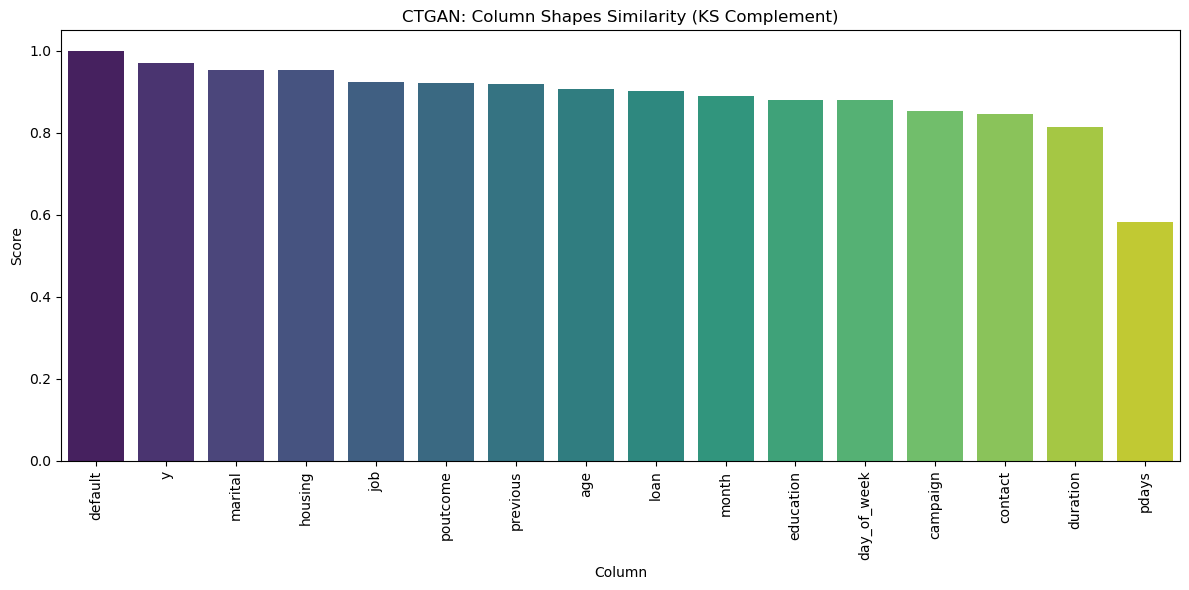

In [20]:
from sdv.evaluation.single_table import QualityReport
import matplotlib.pyplot as plt, seaborn as sns
quality_report_ctgan_ks = QualityReport()
quality_report_ctgan_ks.generate(
    real_data=data,
    synthetic_data=synthetic_data_ctgan,
    metadata=metadata.to_dict()  
)

details_ctgan = quality_report_ctgan_ks.get_details('Column Shapes')
print(details_ctgan)

plt.figure(figsize=(12,6))
sns.barplot(
    x='Column', y='Score',
    data=details_ctgan.sort_values('Score', ascending=False),
    palette='viridis'
)
plt.title('CTGAN: Column Shapes Similarity (KS Complement)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 1.2 Jensen-Shannon Divergence


        Feature  JS_Divergence
13     previous       0.000000
2       marital       0.004419
1           job       0.008475
14     poutcome       0.012672
9   day_of_week       0.014133
8         month       0.016204
3     education       0.016463
0           age       0.018594
11     campaign       0.024609
10     duration       0.063587
12        pdays       0.267127
7       contact       0.707995
6          loan       0.708434
4       default       0.709447
5       housing       0.710422
15            y       0.711446


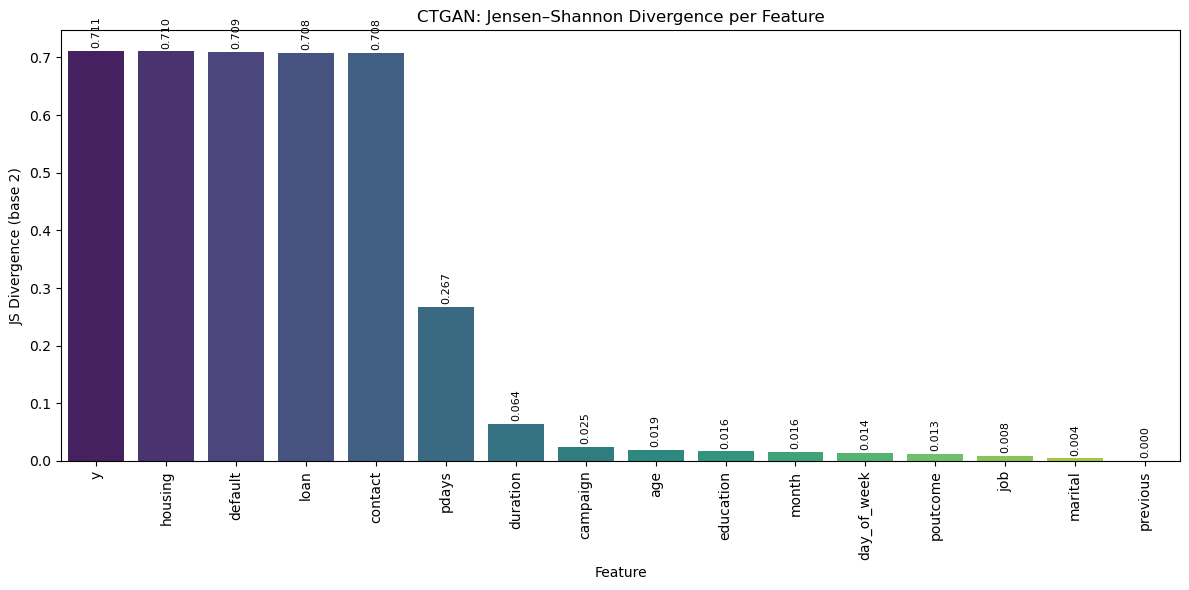

In [21]:
results_ctgan_js = compute_js_divergence(data, synthetic_data_ctgan, bins="fd", normalize=True)
print(results_ctgan_js)

results_ctgan_js_sorted = results_ctgan_js.sort_values("JS_Divergence", ascending=False)
plt.figure(figsize=(12,6))
bars = sns.barplot(x="Feature", y="JS_Divergence", data=results_ctgan_js_sorted, palette="viridis")

for bar in bars.patches:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.3f}",
             ha="center", va="bottom", fontsize=8, rotation=90)

plt.xticks(rotation=90)
plt.ylabel("JS Divergence (base 2)")
plt.title("CTGAN: Jensen–Shannon Divergence per Feature")
plt.tight_layout()
plt.show()


### 1.3 Wasserstein Distance


In [22]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# 1️⃣ Keep only numeric columns (important)
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

real_num = data[num_cols].copy()
synthetic_num = synthetic_data_ctgan[num_cols].copy()

# 2️⃣ Scale using MinMaxScaler (fit ONLY on real data)
scaler_ctgan = MinMaxScaler()

real_scaled_ctgan = pd.DataFrame(
    scaler_ctgan.fit_transform(real_num),
    columns=num_cols
)

synthetic_scaled_ctgan = pd.DataFrame(
    scaler_ctgan.transform(synthetic_num),
    columns=num_cols
)

# 3️⃣ Compute Wasserstein distance
print("CTGAN - Wasserstein Distance:")
for col in num_cols:
    dist = wasserstein_distance(
        real_scaled_ctgan[col],
        synthetic_scaled_ctgan[col]
    )
    print(f"{col}: {dist:.4f}")

CTGAN - Wasserstein Distance:
age: 0.0168
duration: 0.0096
campaign: 0.0074
pdays: 0.0495
previous: 0.0321


### 1.4 Gower Distance


In [26]:
import gower
X_real_ctgan = data.drop('y', axis=1)
X_synth_ctgan = synthetic_data_ctgan.drop('y', axis=1) 

gower_real_ctgan = 1 - gower.gower_matrix(X_real_ctgan)
gower_synth_ctgan = 1 - gower.gower_matrix(X_synth_ctgan)
gower_combined_ctgan = 1 - gower.gower_matrix(pd.concat([X_real_ctgan, X_synth_ctgan], axis=0))

real_upper_ctgan = gower_real_ctgan[np.triu_indices_from(gower_real_ctgan, k=1)]
synth_upper_ctgan = gower_synth_ctgan[np.triu_indices_from(gower_synth_ctgan, k=1)]

max_intra_real_ctgan = np.max(real_upper_ctgan)
avg_intra_real_ctgan = np.mean(real_upper_ctgan)
max_intra_synth_ctgan = np.max(synth_upper_ctgan)
avg_intra_synth_ctgan = np.mean(synth_upper_ctgan)

cross_flat_ctgan = gower_combined_ctgan.flatten()
max_cross_ctgan = np.max(cross_flat_ctgan)
avg_cross_ctgan = np.mean(cross_flat_ctgan)

print("CTGAN - Gower Distance:")
print("Intra-set Similarity (Real):")
print(f"Max = {max_intra_real_ctgan:.4f}, Avg = {avg_intra_real_ctgan:.4f}\n")
print("Intra-set Similarity (Synthetic):")
print(f"Max = {max_intra_synth_ctgan:.4f}, Avg = {avg_intra_synth_ctgan:.4f}\n")
print("Cross-set Similarity (Real vs Synthetic):")
print(f"Max = {max_cross_ctgan:.4f}, Avg = {avg_cross_ctgan:.4f}")


CTGAN - Gower Distance:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.5377

Intra-set Similarity (Synthetic):
Max = 0.9998, Avg = 0.5010

Cross-set Similarity (Real vs Synthetic):
Max = 1.0000, Avg = 0.5191


### 1.5 t-SNE Visualization


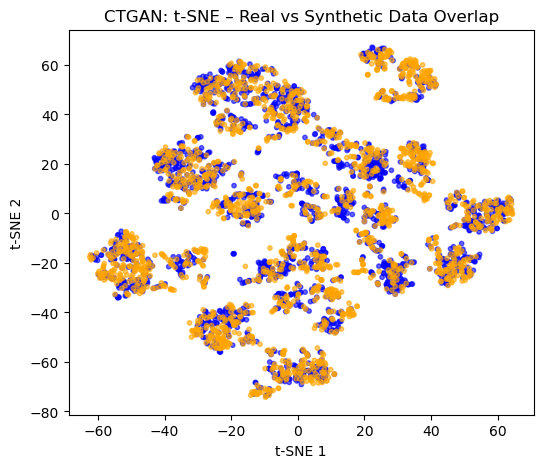

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE

# -----------------------------
# Settings
# -----------------------------
RANDOM_STATE = 42
N = 2000  # safe for t-SNE

np.random.seed(RANDOM_STATE)

# -----------------------------
# Subsample real & synthetic
# -----------------------------
real_tsne = data.sample(n=N, random_state=RANDOM_STATE).drop(columns=['y'])
synth_tsne = synthetic_data_ctgan.sample(n=N, random_state=RANDOM_STATE).drop(columns=['y'])

# -----------------------------
# Identify columns
# -----------------------------
cat_cols = real_tsne.select_dtypes(include='object').columns
num_cols = real_tsne.select_dtypes(exclude='object').columns

# -----------------------------
# Impute missing values
# -----------------------------
cat_imputer = SimpleImputer(strategy='most_frequent')
num_imputer = SimpleImputer(strategy='median')

real_cat_imp = cat_imputer.fit_transform(real_tsne[cat_cols])
synth_cat_imp = cat_imputer.transform(synth_tsne[cat_cols])

real_num_imp = num_imputer.fit_transform(real_tsne[num_cols])
synth_num_imp = num_imputer.transform(synth_tsne[num_cols])

# -----------------------------
# Encode categorical features
# -----------------------------
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

real_cat_enc = encoder.fit_transform(real_cat_imp)
synth_cat_enc = encoder.transform(synth_cat_imp)

# -----------------------------
# Scale numerical features
# -----------------------------
scaler = StandardScaler()

real_num_scaled = scaler.fit_transform(real_num_imp)
synth_num_scaled = scaler.transform(synth_num_imp)

# -----------------------------
# Combine features
# -----------------------------
real_scaled = np.hstack([real_num_scaled, real_cat_enc])
synth_scaled = np.hstack([synth_num_scaled, synth_cat_enc])

combined = np.vstack([real_scaled, synth_scaled])

labels = np.array(
    ['Real'] * len(real_scaled) +
    ['Synthetic'] * len(synth_scaled)
)

# -----------------------------
# Run t-SNE
# -----------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=RANDOM_STATE
)

tsne_result = tsne.fit_transform(combined)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6, 5))

colors = np.where(labels == 'Real', 'blue', 'orange')

plt.scatter(
    tsne_result[:, 0],
    tsne_result[:, 1],
    c=colors,
    alpha=0.6,
    s=10
)

plt.title("CTGAN: t-SNE – Real vs Synthetic Data Overlap")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

### 1.6 MMD (Maximum Mean Discrepancy)


In [30]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Select numeric columns
# -----------------------------
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != 'y']

real_num = data[num_cols].values
synthetic_num = synthetic_data_ctgan[num_cols].values

# -----------------------------
# Standardize (fit on real only)
# -----------------------------
scaler = StandardScaler()
real_scaled = scaler.fit_transform(real_num)
synthetic_scaled = scaler.transform(synthetic_num)

# -----------------------------
# Linear-time RBF MMD (FIXED)
# -----------------------------
def linear_mmd(x, y, sigma=1.0, random_state=42):
    rng = np.random.default_rng(random_state)

    n = min(len(x), len(y))

    # FORCE EVEN SAMPLE SIZE
    n = n - (n % 2)

    # Randomly sample n points from each
    idx_x = rng.choice(len(x), n, replace=False)
    idx_y = rng.choice(len(y), n, replace=False)

    x = x[idx_x]
    y = y[idx_y]

    # Pair samples
    x1, x2 = x[0::2], x[1::2]
    y1, y2 = y[0::2], y[1::2]

    def rbf(a, b):
        return np.exp(-np.sum((a - b) ** 2, axis=1) / (2 * sigma ** 2))

    k_xx = np.mean(rbf(x1, x2))
    k_yy = np.mean(rbf(y1, y2))
    k_xy = np.mean(rbf(x1, y2))

    return k_xx + k_yy - 2 * k_xy

# -----------------------------
# Compute MMD
# -----------------------------
mmd_score_ctgan = linear_mmd(real_scaled, synthetic_scaled, sigma=1.0)

print(f"CTGAN – Linear MMD score: {mmd_score_ctgan:.6f}")

CTGAN – Linear MMD score: -0.007274


### 1.7 Cosine Similarity


In [32]:
from sklearn.metrics.pairwise import cosine_similarity

# Ensure equal sample size (important)
n = min(len(real_scaled), len(synthetic_scaled))

real_scaled_ctgan = real_scaled[:n]
synthetic_scaled_ctgan = synthetic_scaled[:n]

# -----------------------------
# Compute cosine similarity
# -----------------------------
cross_sim_ctgan = cosine_similarity(
    real_scaled_ctgan,
    synthetic_scaled_ctgan
)

avg_sim_ctgan = np.mean(cross_sim_ctgan)
max_sim_ctgan = np.max(cross_sim_ctgan)

print("CTGAN – Sample-Level Cosine Similarity:")
print(f"Average cosine similarity: {avg_sim_ctgan:.4f}")
print(f"Maximum cosine similarity: {max_sim_ctgan:.4f}") 


CTGAN – Sample-Level Cosine Similarity:
Average cosine similarity: 0.0361
Maximum cosine similarity: 1.0000


### 5.9 Privacy Check


In [33]:
from sklearn.neighbors import NearestNeighbors

# -----------------------------
# Reuse scaled numeric data
# -----------------------------
# These must already exist from MMD:
# real_scaled
# synthetic_scaled

# Ensure equal dimensionality
assert real_scaled.shape[1] == synthetic_scaled.shape[1]

# Fit NN on REAL data
nn_ctgan = NearestNeighbors(
    n_neighbors=1,
    metric='euclidean'
).fit(real_scaled)

# Query with SYNTHETIC data
distances_ctgan, _ = nn_ctgan.kneighbors(synthetic_scaled)

avg_nn_dist_ctgan = distances_ctgan.mean()
min_nn_dist_ctgan = distances_ctgan.min()

print("CTGAN – Privacy Check (Numeric Features):")
print(f"Average Nearest Neighbor Distance (Synthetic → Real): {avg_nn_dist_ctgan:.4f}")
print(f"Minimum Nearest Neighbor Distance (Worst Case): {min_nn_dist_ctgan:.4f}")

CTGAN – Privacy Check (Numeric Features):
Average Nearest Neighbor Distance (Synthetic → Real): 0.1552
Minimum Nearest Neighbor Distance (Worst Case): 0.0000


### 1.10 Bivariate Analysis


In [36]:
# Numeric columns EXCEPT target
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != 'y']

# Add y back explicitly
real_num_ctgan = data[num_cols + ['y']].copy()
synth_num_ctgan = synthetic_data_ctgan[num_cols + ['y']].copy()

# Ensure alignment
synth_num_ctgan = synth_num_ctgan[real_num_ctgan.columns]

corr_results_ctgan, target_results_ctgan = bivariate_quality_banking(
    real_df=real_num_ctgan,
    synth_df=synth_num_ctgan
)


# ------------------------------------
# 4️⃣ Display results
# ------------------------------------
print("CTGAN – Largest differences in pairwise correlations:")
print(corr_results_ctgan.head(10))

print("\n================================")
print("CTGAN – Features that differ most by target class:")
print(target_results_ctgan.head(10))

CTGAN – Largest differences in pairwise correlations:
      var_a     var_b  delta_corr
9     pdays  previous    0.139507
2       age     pdays    0.106219
3       age  previous    0.075487
5  duration     pdays    0.074095
4  duration  campaign    0.060106
7  campaign     pdays    0.033204
8  campaign  previous    0.030428
1       age  campaign    0.027528
6  duration  previous    0.020748
0       age  duration    0.003239

CTGAN – Features that differ most by target class:
    feature  delta_wasserstein
3     pdays           0.004752
4  previous           0.002241
1  duration           0.000955
0       age           0.000503
2  campaign           0.000159


### 1.11 Multivariate Analysis


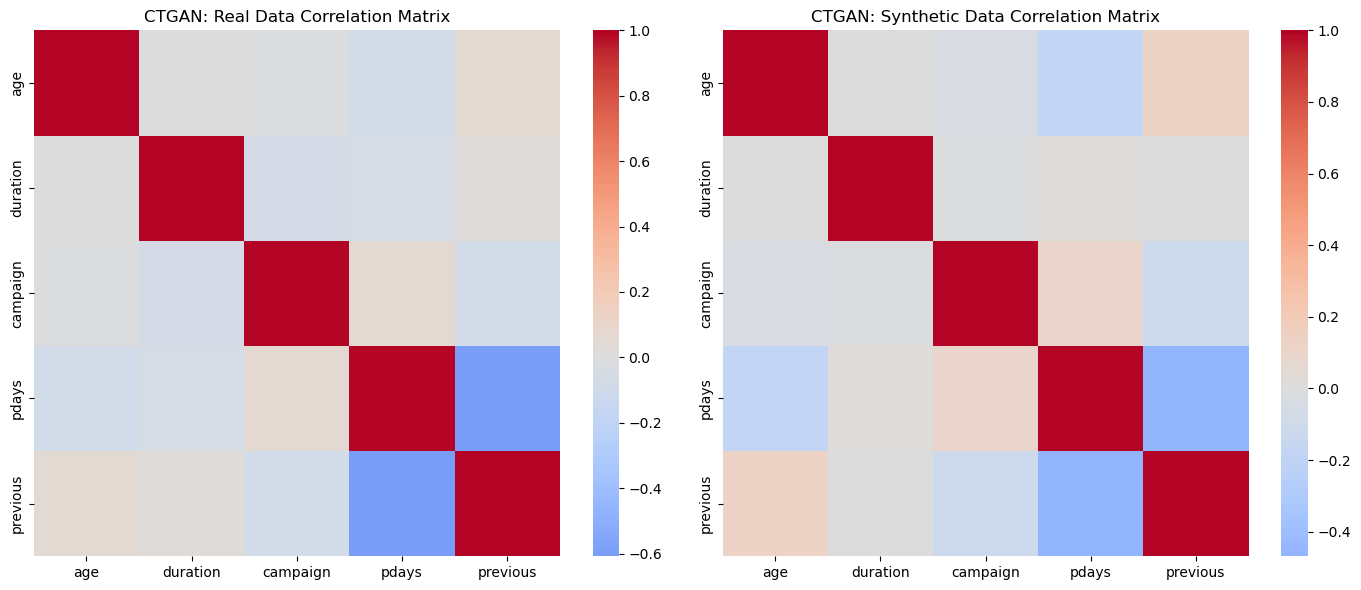

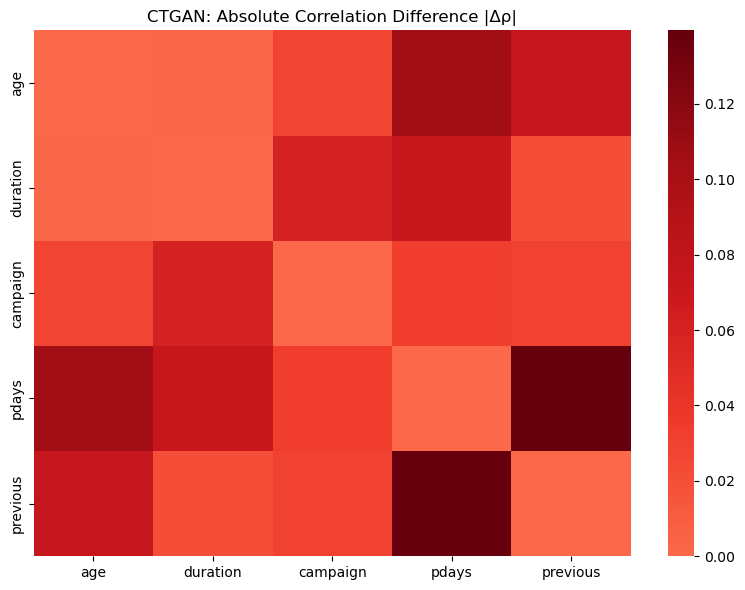

In [37]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != 'y']

real_df_ctgan = data[num_cols]
synth_df_ctgan = synthetic_data_ctgan[num_cols]

# ------------------------------------
# Correlation heatmaps
# ------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    real_df_ctgan.corr(),
    cmap="coolwarm",
    center=0,
    ax=axes[0]
)
axes[0].set_title("CTGAN: Real Data Correlation Matrix")

sns.heatmap(
    synth_df_ctgan.corr(),
    cmap="coolwarm",
    center=0,
    ax=axes[1]
)
axes[1].set_title("CTGAN: Synthetic Data Correlation Matrix")

plt.tight_layout()
plt.show()

# ------------------------------------
# Absolute correlation difference
# ------------------------------------
diff_corr_ctgan = (real_df_ctgan.corr() - synth_df_ctgan.corr()).abs()

plt.figure(figsize=(8, 6))
sns.heatmap(
    diff_corr_ctgan,
    cmap="Reds",
    center=0
)
plt.title("CTGAN: Absolute Correlation Difference |Δρ|")
plt.tight_layout()
plt.show()

---

## 2. CopulaGAN Model

CopulaGAN is a GAN-based synthetic data generator for tabular data that uses copulas to better model dependencies between features.

**GAN component**: Learns the overall data distribution and generates synthetic samples.

**Copula component**: Models dependence structure between columns, especially useful for non-Gaussian or skewed distributions.


In [38]:
from sdv.single_table import CopulaGANSynthesizer
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

# Train CopulaGAN model
copulagan = CopulaGANSynthesizer(metadata)
copulagan.fit(data)
synthetic_data_copulagan = copulagan.sample(10000)

# Diagnostic and quality check
diagnostic_report_copulagan = run_diagnostic(data, synthetic_data_copulagan, metadata) 
quality_report_copulagan = evaluate_quality(data, synthetic_data_copulagan, metadata)


Generating report ...

(1/2) Evaluating Data Validity: |██████████| 16/16 [00:00<00:00, 592.43it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 333.30it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:00<00:00, 63.59it/s]|
Column Shapes Score: 90.79%

(2/2) Evaluating Column Pair Trends: |██████████| 120/120 [00:00<00:00, 192.15it/s]|
Column Pair Trends Score: 83.09%

Overall Score (Average): 86.94%



### 2.1 Kolmogorov-Smirnov (KS) Test


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:00<00:00, 62.77it/s]|
Column Shapes Score: 90.79%

(2/2) Evaluating Column Pair Trends: |██████████| 120/120 [00:00<00:00, 175.63it/s]|
Column Pair Trends Score: 83.09%

Overall Score (Average): 86.94%

         Column        Metric     Score
0           age  KSComplement  0.935459
1           job  TVComplement  0.868953
2       marital  TVComplement  0.924162
3     education  TVComplement  0.852566
4       default  TVComplement  1.000000
5       housing  TVComplement  0.944341
6          loan  TVComplement  0.917344
7       contact  TVComplement  0.813359
8         month  TVComplement  0.879067
9   day_of_week  TVComplement  0.835729
10     duration  KSComplement  0.910725
11     campaign  KSComplement  0.916897
12        pdays  KSComplement  0.931043
13     previous  TVComplement  0.912488
14     poutcome  TVComplement  0.911088
15            y  TVComplement  0.973445


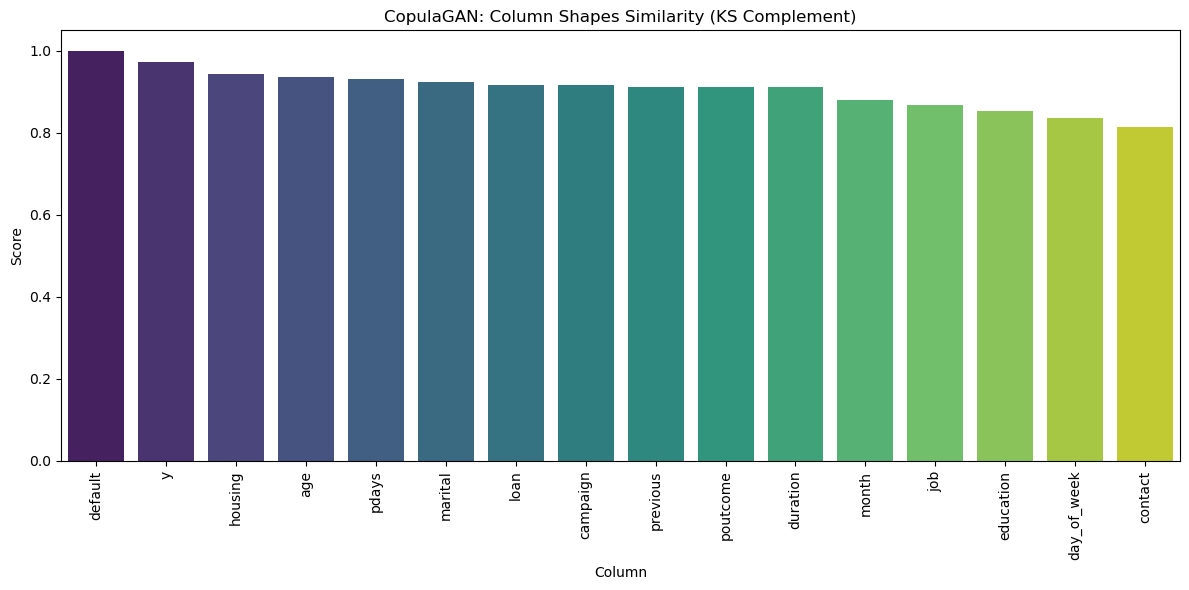

In [39]:
from sdv.evaluation.single_table import QualityReport
import seaborn as sns
import matplotlib.pyplot as plt

# Generate quality report for CopulaGAN
quality_report_copulagan_ks = QualityReport()
quality_report_copulagan_ks.generate(
    real_data=data,
    synthetic_data=synthetic_data_copulagan,
    metadata=metadata.to_dict()  
)

details_copulagan = quality_report_copulagan_ks.get_details('Column Shapes')
print(details_copulagan)

# Visualization
plt.figure(figsize=(12,6))
sns.barplot(
    x='Column', y='Score',
    data=details_copulagan.sort_values('Score', ascending=False),
    palette='viridis'
)
plt.title('CopulaGAN: Column Shapes Similarity (KS Complement)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 2.2 Jensen-Shannon Divergence


        Feature  JS_Divergence
12        pdays       0.000000
13     previous       0.000000
2       marital       0.004580
8         month       0.012178
14     poutcome       0.012967
0           age       0.014351
1           job       0.014590
3     education       0.018914
10     duration       0.023468
9   day_of_week       0.025367
11     campaign       0.029174
6          loan       0.711893
5       housing       0.713150
15            y       0.714507
7       contact       0.715599
4       default       0.717389


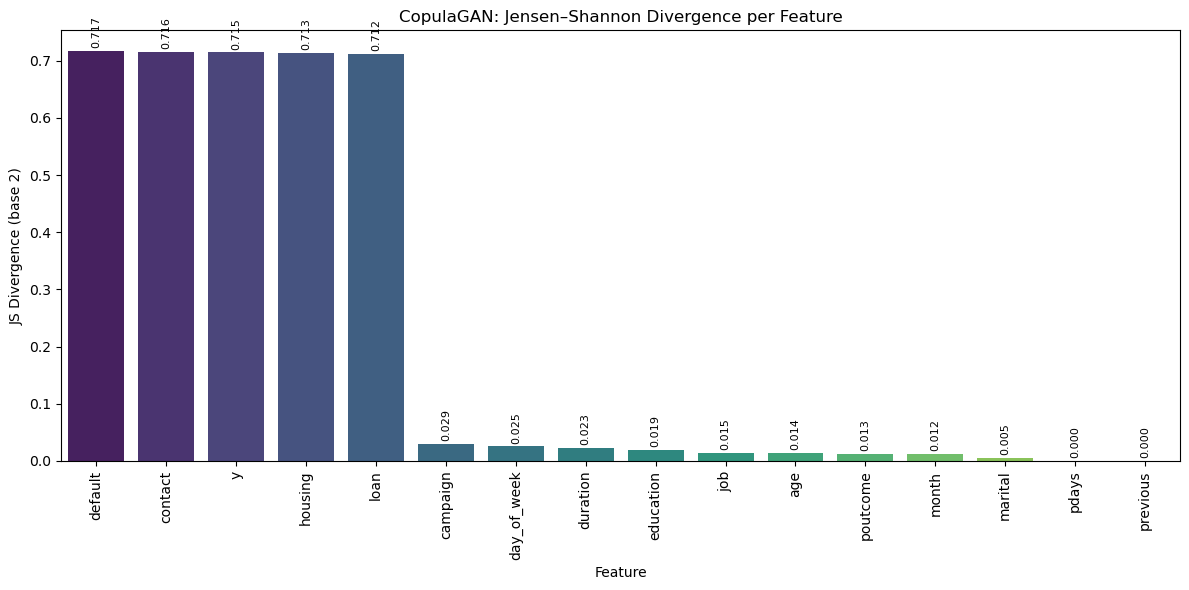

In [40]:
results_copulagan_js = compute_js_divergence(data, synthetic_data_copulagan, bins="fd", normalize=True)
print(results_copulagan_js)

# Visualization
results_copulagan_js_sorted = results_copulagan_js.sort_values("JS_Divergence", ascending=False)
plt.figure(figsize=(12,6))
bars = sns.barplot(x="Feature", y="JS_Divergence", data=results_copulagan_js_sorted, palette="viridis")

for bar in bars.patches:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 0.005,
        f"{yval:.3f}",
        ha="center", va="bottom", fontsize=8, rotation=90
    )

plt.xticks(rotation=90)
plt.ylabel("JS Divergence (base 2)")
plt.title("CopulaGAN: Jensen–Shannon Divergence per Feature")
plt.tight_layout()
plt.show()


### 2.3 Wasserstein Distance


In [42]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# 1️⃣ Keep only numeric columns (important)
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

real_num = data[num_cols].copy()
synthetic_num = synthetic_data_copulagan[num_cols].copy()

# 2️⃣ Scale using MinMaxScaler (fit ONLY on real data)
scaler_copulagan = MinMaxScaler()

real_scaled_copulagan = pd.DataFrame(
    scaler_copulagan.fit_transform(real_num),
    columns=num_cols
)

synthetic_scaled_copulagan = pd.DataFrame(
    scaler_copulagan.transform(synthetic_num),
    columns=num_cols
)

# 3️⃣ Compute Wasserstein distance
print("CopulaGAN - Wasserstein Distance:")
for col in num_cols:
    dist = wasserstein_distance(
        real_scaled_copulagan[col],
        synthetic_scaled_copulagan[col]
    )
    print(f"{col}: {dist:.4f}")

CopulaGAN - Wasserstein Distance:
age: 0.0154
duration: 0.0069
campaign: 0.0083
pdays: 0.0677
previous: 0.0322


### 2.4 Gower Distance


In [43]:
import gower
X_real_copulagan = data.drop('y', axis=1)
X_synth_copulagan = synthetic_data_copulagan.drop('y', axis=1) 

gower_real_copulagan = 1 - gower.gower_matrix(X_real_copulagan)
gower_synth_copulagan = 1 - gower.gower_matrix(X_synth_copulagan)
gower_combined_copulagan = 1 - gower.gower_matrix(pd.concat([X_real_copulagan, X_synth_copulagan], axis=0))

real_upper_copulagan = gower_real_copulagan[np.triu_indices_from(gower_real_copulagan, k=1)]
synth_upper_copulagan = gower_synth_copulagan[np.triu_indices_from(gower_synth_copulagan, k=1)]

max_intra_real_copulagan = np.max(real_upper_copulagan)
avg_intra_real_copulagan = np.mean(real_upper_copulagan)
max_intra_synth_copulagan = np.max(synth_upper_copulagan)
avg_intra_synth_copulagan = np.mean(synth_upper_copulagan)

cross_flat_copulagan = gower_combined_copulagan.flatten()
max_cross_copulagan = np.max(cross_flat_copulagan)
avg_cross_copulagan = np.mean(cross_flat_copulagan)

print("CopulaGAN - Gower Distance:")
print("Intra-set Similarity (Real):")
print(f"Max = {max_intra_real_copulagan:.4f}, Avg = {avg_intra_real_copulagan:.4f}\n")
print("Intra-set Similarity (Synthetic):")
print(f"Max = {max_intra_synth_copulagan:.4f}, Avg = {avg_intra_synth_copulagan:.4f}\n")
print("Cross-set Similarity (Real vs Synthetic):")
print(f"Max = {max_cross_copulagan:.4f}, Avg = {avg_cross_copulagan:.4f}")

CopulaGAN - Gower Distance:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.5377

Intra-set Similarity (Synthetic):
Max = 0.9999, Avg = 0.4917

Cross-set Similarity (Real vs Synthetic):
Max = 1.0000, Avg = 0.5132


### 2.5 t-SNE Visualization


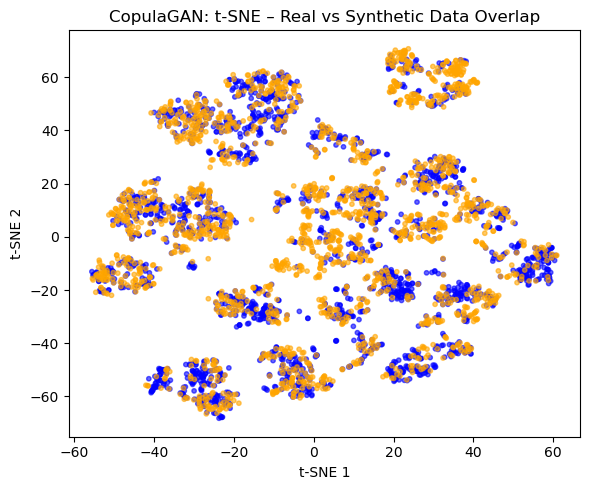

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE

# -----------------------------
# Settings
# -----------------------------
RANDOM_STATE = 42
N = 2000

np.random.seed(RANDOM_STATE)

# -----------------------------
# Subsample real & synthetic
# -----------------------------
real_tsne = data.sample(n=N, random_state=RANDOM_STATE).drop(columns=['y'])
synth_tsne = synthetic_data_copulagan.sample(n=N, random_state=RANDOM_STATE).drop(columns=['y'])

# Ensure same column order
synth_tsne = synth_tsne[real_tsne.columns]

# -----------------------------
# Identify columns
# -----------------------------
cat_cols = real_tsne.select_dtypes(include='object').columns
num_cols = real_tsne.select_dtypes(exclude='object').columns

# -----------------------------
# Impute missing values
# -----------------------------
cat_imputer = SimpleImputer(strategy='most_frequent')
num_imputer = SimpleImputer(strategy='median')

real_cat_imp = cat_imputer.fit_transform(real_tsne[cat_cols])
synth_cat_imp = cat_imputer.transform(synth_tsne[cat_cols])

real_num_imp = num_imputer.fit_transform(real_tsne[num_cols])
synth_num_imp = num_imputer.transform(synth_tsne[num_cols])

# -----------------------------
# Encode categorical features
# -----------------------------
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

real_cat_enc = encoder.fit_transform(real_cat_imp)
synth_cat_enc = encoder.transform(synth_cat_imp)

# -----------------------------
# Scale numerical features
# -----------------------------
scaler = StandardScaler()

real_num_scaled = scaler.fit_transform(real_num_imp)
synth_num_scaled = scaler.transform(synth_num_imp)

# -----------------------------
# Combine features
# -----------------------------
real_scaled = np.hstack([real_num_scaled, real_cat_enc])
synth_scaled = np.hstack([synth_num_scaled, synth_cat_enc])

combined = np.vstack([real_scaled, synth_scaled])

labels = np.array(
    ['Real'] * len(real_scaled) +
    ['Synthetic'] * len(synth_scaled)
)

# -----------------------------
# Run t-SNE
# -----------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=RANDOM_STATE
)

tsne_result = tsne.fit_transform(combined)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6, 5))

colors = np.where(labels == 'Real', 'blue', 'orange')

plt.scatter(
    tsne_result[:, 0],
    tsne_result[:, 1],
    c=colors,
    alpha=0.6,
    s=10
)

plt.title("CopulaGAN: t-SNE – Real vs Synthetic Data Overlap")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

### 2.6 MMD (Maximum Mean Discrepancy)


In [45]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Select numeric columns
# -----------------------------
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != 'y']  # exclude target if present

real_num = data[num_cols].values
synthetic_num = synthetic_data_copulagan[num_cols].values

# -----------------------------
# Standardize (fit on real only)
# -----------------------------
scaler = StandardScaler()
real_scaled = scaler.fit_transform(real_num)
synthetic_scaled = scaler.transform(synthetic_num)

# -----------------------------
# Linear-time RBF MMD
# -----------------------------
def linear_mmd(x, y, sigma=1.0, random_state=42):
    rng = np.random.default_rng(random_state)

    n = min(len(x), len(y))

    # Force even sample size
    n = n - (n % 2)

    # Random subsampling
    idx_x = rng.choice(len(x), n, replace=False)
    idx_y = rng.choice(len(y), n, replace=False)

    x = x[idx_x]
    y = y[idx_y]

    # Pair samples
    x1, x2 = x[0::2], x[1::2]
    y1, y2 = y[0::2], y[1::2]

    def rbf(a, b):
        return np.exp(-np.sum((a - b) ** 2, axis=1) / (2 * sigma ** 2))

    k_xx = np.mean(rbf(x1, x2))
    k_yy = np.mean(rbf(y1, y2))
    k_xy = np.mean(rbf(x1, y2))

    return k_xx + k_yy - 2 * k_xy

# -----------------------------
# Compute MMD
# -----------------------------
mmd_score_copulagan = linear_mmd(
    real_scaled,
    synthetic_scaled,
    sigma=1.0
)

print(f"CopulaGAN – Linear MMD score: {mmd_score_copulagan:.6f}")

CopulaGAN – Linear MMD score: -0.003246


### 2.7 Cosine Similarity


In [46]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# -----------------------------
# Ensure equal sample size
# -----------------------------
n = min(len(real_scaled), len(synthetic_scaled))

real_scaled_copulagan = real_scaled[:n]
synthetic_scaled_copulagan = synthetic_scaled[:n]

# -----------------------------
# Compute cosine similarity
# -----------------------------
cross_sim_copulagan = cosine_similarity(
    real_scaled_copulagan,
    synthetic_scaled_copulagan
)

avg_sim_copulagan = cross_sim_copulagan.mean()
max_sim_copulagan = cross_sim_copulagan.max()

print("CopulaGAN – Sample-Level Cosine Similarity:")
print(f"Average cosine similarity: {avg_sim_copulagan:.4f}")
print(f"Maximum cosine similarity: {max_sim_copulagan:.4f}")

CopulaGAN – Sample-Level Cosine Similarity:
Average cosine similarity: 0.0359
Maximum cosine similarity: 1.0000


### 2.9 Privacy Check


In [47]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# -----------------------------
# Reuse scaled numeric data
# -----------------------------
# These must already exist from CopulaGAN MMD step:
# real_scaled        -> scaled real numeric data
# synthetic_scaled   -> scaled CopulaGAN numeric data

# Ensure equal dimensionality
assert real_scaled.shape[1] == synthetic_scaled.shape[1]

# -----------------------------
# Fit NN on REAL data
# -----------------------------
nn_copulagan = NearestNeighbors(
    n_neighbors=1,
    metric='euclidean'
).fit(real_scaled)

# -----------------------------
# Query with SYNTHETIC data
# -----------------------------
distances_copulagan, _ = nn_copulagan.kneighbors(synthetic_scaled)

avg_nn_dist_copulagan = distances_copulagan.mean()
min_nn_dist_copulagan = distances_copulagan.min()

print("CopulaGAN – Privacy Check (Numeric Features):")
print(f"Average Nearest Neighbor Distance (Synthetic → Real): {avg_nn_dist_copulagan:.4f}")
print(f"Minimum Nearest Neighbor Distance (Worst Case): {min_nn_dist_copulagan:.4f}")

CopulaGAN – Privacy Check (Numeric Features):
Average Nearest Neighbor Distance (Synthetic → Real): 0.1519
Minimum Nearest Neighbor Distance (Worst Case): 0.0000


### 2.10 Bivariate Analysis


In [48]:
# Numeric columns EXCEPT target
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != 'y']

# Add y back explicitly
real_num_copulagan = data[num_cols + ['y']].copy()
synth_num_copulagan = synthetic_data_copulagan[num_cols + ['y']].copy()

# Ensure alignment
synth_num_copulagan = synth_num_copulagan[real_num_copulagan.columns]

# Run bivariate quality
corr_results_copulagan, target_results_copulagan = bivariate_quality_banking(
    real_df=real_num_copulagan,
    synth_df=synth_num_copulagan
)

# ------------------------------------
# Display results
# ------------------------------------
print("CopulaGAN – Largest differences in pairwise correlations:")
print(corr_results_copulagan.head(10))

print("\n================================")
print("CopulaGAN – Features that differ most by target class:")
print(target_results_copulagan.head(10))

CopulaGAN – Largest differences in pairwise correlations:
      var_a     var_b  delta_corr
9     pdays  previous    0.146400
2       age     pdays    0.088889
6  duration  previous    0.076917
7  campaign     pdays    0.064104
8  campaign  previous    0.052660
4  duration  campaign    0.051371
1       age  campaign    0.048812
5  duration     pdays    0.043404
3       age  previous    0.041185
0       age  duration    0.003248

CopulaGAN – Features that differ most by target class:
    feature  delta_wasserstein
3     pdays           0.013547
4  previous           0.010213
0       age           0.003293
1  duration           0.002087
2  campaign           0.000183


### 2.11 Multivariate Analysis


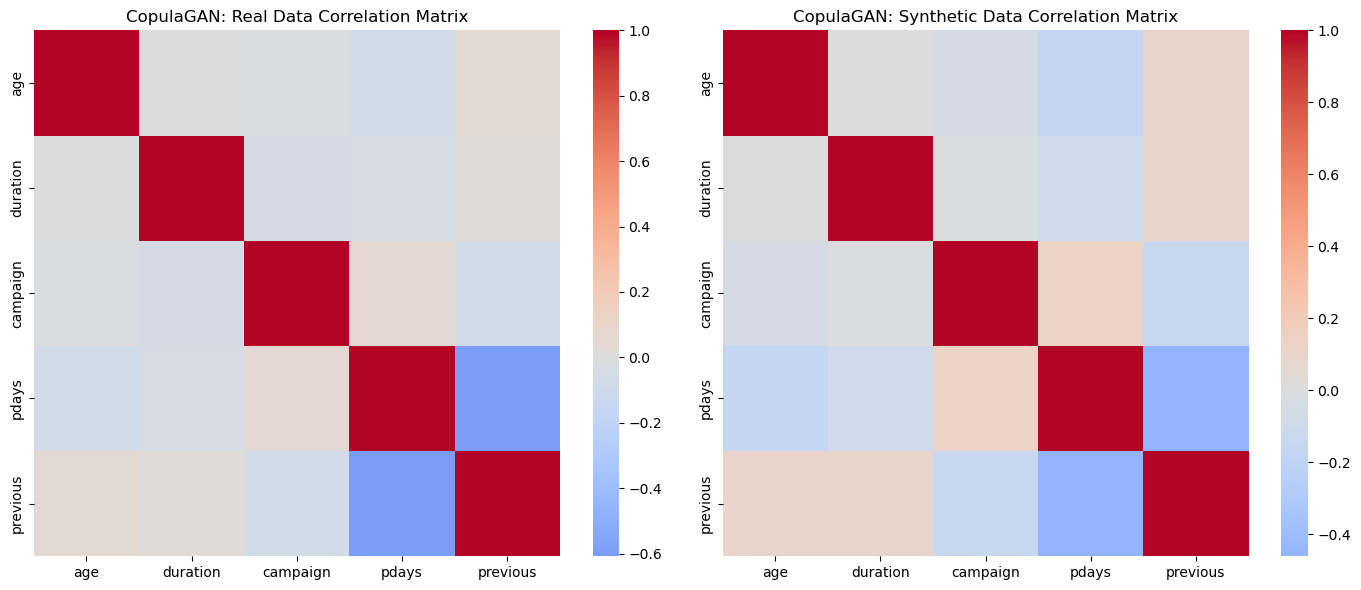

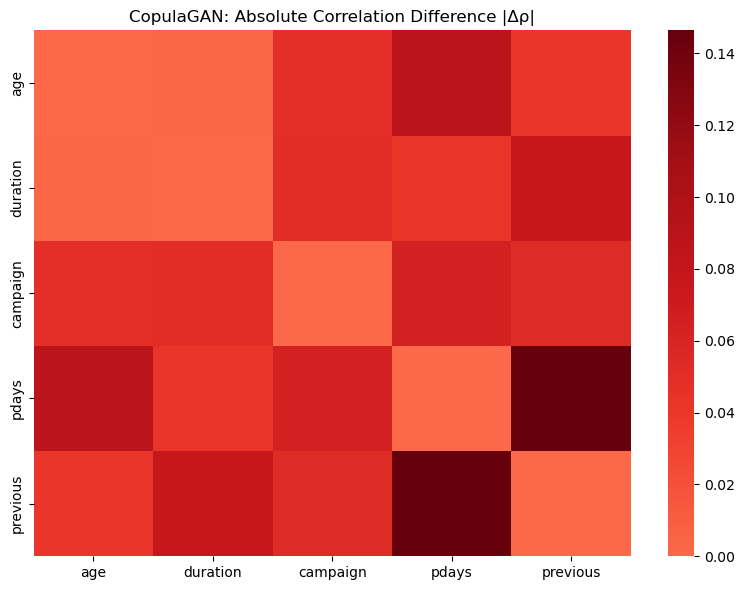

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------
# Select numeric columns (exclude target)
# ------------------------------------
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != 'y']

real_df_copulagan = data[num_cols]
synth_df_copulagan = synthetic_data_copulagan[num_cols]

# ------------------------------------
# Correlation heatmaps
# ------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    real_df_copulagan.corr(),
    cmap="coolwarm",
    center=0,
    ax=axes[0]
)
axes[0].set_title("CopulaGAN: Real Data Correlation Matrix")

sns.heatmap(
    synth_df_copulagan.corr(),
    cmap="coolwarm",
    center=0,
    ax=axes[1]
)
axes[1].set_title("CopulaGAN: Synthetic Data Correlation Matrix")

plt.tight_layout()
plt.show()

# ------------------------------------
# Absolute correlation difference
# ------------------------------------
diff_corr_copulagan = (real_df_copulagan.corr() - synth_df_copulagan.corr()).abs()

plt.figure(figsize=(8, 6))
sns.heatmap(
    diff_corr_copulagan,
    cmap="Reds",
    center=0
)
plt.title("CopulaGAN: Absolute Correlation Difference |Δρ|")
plt.tight_layout()
plt.show()

# 3. Gaussian Copula 

In [51]:
from sdv.single_table import GaussianCopulaSynthesizer

# Train Gaussian Copula model
gaussiancopula = GaussianCopulaSynthesizer(metadata)
gaussiancopula.fit(data)
synthetic_data_gaussiancopula = gaussiancopula.sample(num_rows=10000)

# Diagnostic and quality check
diagnostic_report_gaussiancopula = run_diagnostic(data, synthetic_data_gaussiancopula, metadata)
quality_report_gaussiancopula = evaluate_quality(data, synthetic_data_gaussiancopula, metadata)


Generating report ...

(1/2) Evaluating Data Validity: |██████████| 16/16 [00:00<00:00, 528.35it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 331.36it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:00<00:00, 29.08it/s]|
Column Shapes Score: 93.61%

(2/2) Evaluating Column Pair Trends: |██████████| 120/120 [00:00<00:00, 232.79it/s]|
Column Pair Trends Score: 82.89%

Overall Score (Average): 88.25%



### 3.1 Kolmogorov-Smirnov (KS) Test


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:00<00:00, 32.78it/s]|
Column Shapes Score: 93.61%

(2/2) Evaluating Column Pair Trends: |██████████| 120/120 [00:00<00:00, 249.71it/s]|
Column Pair Trends Score: 82.89%

Overall Score (Average): 88.25%

         Column        Metric     Score
0           age  KSComplement  0.963508
1           job  TVComplement  0.988539
2       marital  TVComplement  0.994733
3     education  TVComplement  0.994814
4       default  TVComplement  1.000000
5       housing  TVComplement  0.989155
6          loan  TVComplement  0.992477
7       contact  TVComplement  0.988878
8         month  TVComplement  0.988597
9   day_of_week  TVComplement  0.993480
10     duration  KSComplement  0.938965
11     campaign  KSComplement  0.845597
12        pdays  KSComplement  0.316043
13     previous  TVComplement  0.997577
14     poutcome  TVComplement  0.985788
15            y  TVComplement  0.999320


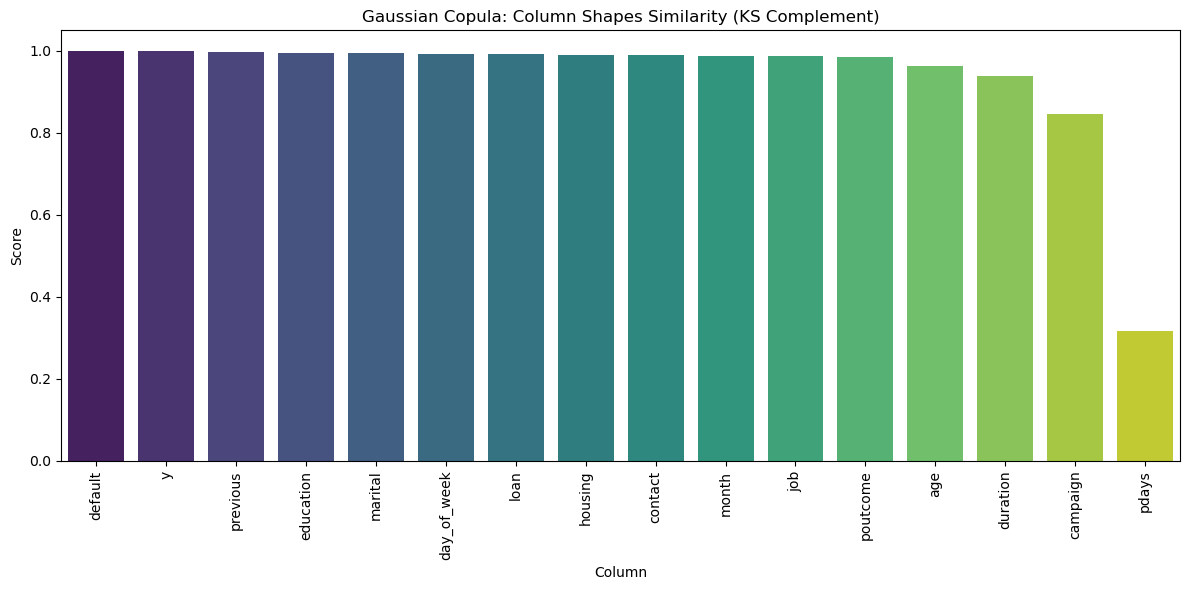

In [52]:
quality_report_gaussiancopula_ks = QualityReport()
quality_report_gaussiancopula_ks.generate(
    real_data=data,
    synthetic_data=synthetic_data_gaussiancopula,
    metadata=metadata.to_dict()  
)

details_gaussiancopula = quality_report_gaussiancopula_ks.get_details('Column Shapes')
print(details_gaussiancopula)

plt.figure(figsize=(12,6))
sns.barplot(
    x='Column', y='Score',
    data=details_gaussiancopula.sort_values('Score', ascending=False),
    palette='viridis'
)
plt.title('Gaussian Copula: Column Shapes Similarity (KS Complement)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### 3.2 Jensen-Shannon Divergence


        Feature  JS_Divergence
13     previous       0.000000
2       marital       0.000024
9   day_of_week       0.000041
5       housing       0.000063
6          loan       0.000063
15            y       0.000092
7       contact       0.000113
1           job       0.000142
3     education       0.000179
8         month       0.000281
4       default       0.000284
14     poutcome       0.000312
0           age       0.012464
10     duration       0.014036
11     campaign       0.021503
12        pdays       0.460048


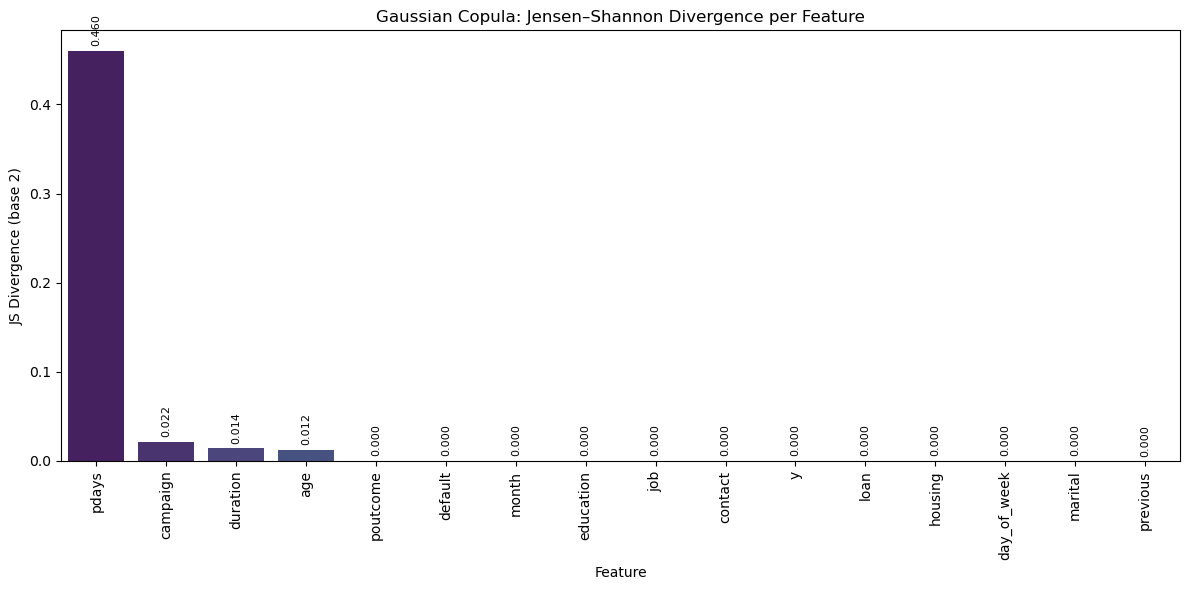

In [53]:
results_gaussiancopula_js = compute_js_divergence(data, synthetic_data_gaussiancopula, bins="fd", normalize=True)
print(results_gaussiancopula_js)

results_gaussiancopula_js_sorted = results_gaussiancopula_js.sort_values("JS_Divergence", ascending=False)
plt.figure(figsize=(12,6))
bars = sns.barplot(x="Feature", y="JS_Divergence", data=results_gaussiancopula_js_sorted, palette="viridis")

for bar in bars.patches:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.3f}",
             ha="center", va="bottom", fontsize=8, rotation=90)

plt.xticks(rotation=90)
plt.ylabel("JS Divergence (base 2)")
plt.title("Gaussian Copula: Jensen–Shannon Divergence per Feature")
plt.tight_layout()
plt.show()


### 3.3 Wasserstein Distance


In [54]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# ------------------------------------
# 1️⃣ Keep only numeric columns
# ------------------------------------
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

real_num = data[num_cols].copy()
synthetic_num = synthetic_data_gaussiancopula[num_cols].copy()

# ------------------------------------
# 2️⃣ Scale using MinMaxScaler (fit ONLY on real data)
# ------------------------------------
scaler_gc = MinMaxScaler()

real_scaled_gc = pd.DataFrame(
    scaler_gc.fit_transform(real_num),
    columns=num_cols
)

synthetic_scaled_gc = pd.DataFrame(
    scaler_gc.transform(synthetic_num),
    columns=num_cols
)

# ------------------------------------
# 3️⃣ Compute Wasserstein distance
# ------------------------------------
print("Gaussian Copula – Wasserstein Distance:")

for col in num_cols:
    dist = wasserstein_distance(
        real_scaled_gc[col],
        synthetic_scaled_gc[col]
    )
    print(f"{col}: {dist:.4f}")

Gaussian Copula – Wasserstein Distance:
age: 0.0095
duration: 0.0055
campaign: 0.0067
pdays: 0.0645
previous: 0.0006


### 3.4 Gower Distance


In [55]:
import gower
import numpy as np
import pandas as pd

X_real_gc = data.drop('y', axis=1)
X_synth_gc = synthetic_data_gaussiancopula.drop('y', axis=1) 

gower_real_gc = 1 - gower.gower_matrix(X_real_gc)
gower_synth_gc = 1 - gower.gower_matrix(X_synth_gc)
gower_combined_gc = 1 - gower.gower_matrix(
    pd.concat([X_real_gc, X_synth_gc], axis=0)
)

real_upper_gc = gower_real_gc[np.triu_indices_from(gower_real_gc, k=1)]
synth_upper_gc = gower_synth_gc[np.triu_indices_from(gower_synth_gc, k=1)]

max_intra_real_gc = np.max(real_upper_gc)
avg_intra_real_gc = np.mean(real_upper_gc)

max_intra_synth_gc = np.max(synth_upper_gc)
avg_intra_synth_gc = np.mean(synth_upper_gc)

cross_flat_gc = gower_combined_gc.flatten()
max_cross_gc = np.max(cross_flat_gc)
avg_cross_gc = np.mean(cross_flat_gc)

print("Gaussian Copula – Gower Distance:")
print("Intra-set Similarity (Real):")
print(f"Max = {max_intra_real_gc:.4f}, Avg = {avg_intra_real_gc:.4f}\n")

print("Intra-set Similarity (Synthetic):")
print(f"Max = {max_intra_synth_gc:.4f}, Avg = {avg_intra_synth_gc:.4f}\n")

print("Cross-set Similarity (Real vs Synthetic):")
print(f"Max = {max_cross_gc:.4f}, Avg = {avg_cross_gc:.4f}")

Gaussian Copula – Gower Distance:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.5377

Intra-set Similarity (Synthetic):
Max = 0.9991, Avg = 0.5313

Cross-set Similarity (Real vs Synthetic):
Max = 1.0000, Avg = 0.5381


### 3.5 t-SNE Visualization


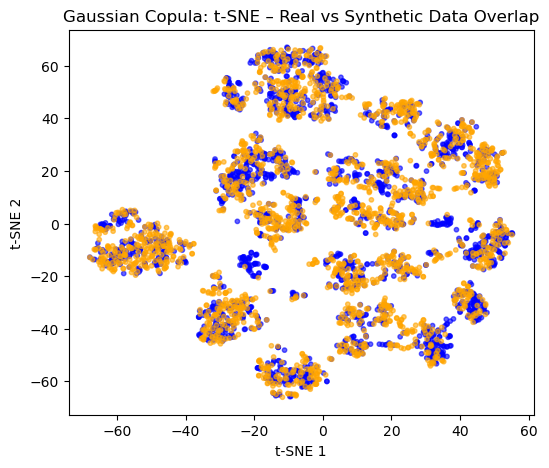

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE

# -----------------------------
# Settings
# -----------------------------
RANDOM_STATE = 42
N = 2000  # safe for t-SNE

np.random.seed(RANDOM_STATE)

# -----------------------------
# Subsample real & synthetic
# -----------------------------
real_tsne = data.sample(n=N, random_state=RANDOM_STATE).drop(columns=['y'])
synth_tsne = synthetic_data_gaussiancopula.sample(n=N, random_state=RANDOM_STATE).drop(columns=['y'])

# -----------------------------
# Identify columns
# -----------------------------
cat_cols = real_tsne.select_dtypes(include='object').columns
num_cols = real_tsne.select_dtypes(exclude='object').columns

# -----------------------------
# Impute missing values
# -----------------------------
cat_imputer = SimpleImputer(strategy='most_frequent')
num_imputer = SimpleImputer(strategy='median')

real_cat_imp = cat_imputer.fit_transform(real_tsne[cat_cols])
synth_cat_imp = cat_imputer.transform(synth_tsne[cat_cols])

real_num_imp = num_imputer.fit_transform(real_tsne[num_cols])
synth_num_imp = num_imputer.transform(synth_tsne[num_cols])

# -----------------------------
# Encode categorical features
# -----------------------------
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

real_cat_enc = encoder.fit_transform(real_cat_imp)
synth_cat_enc = encoder.transform(synth_cat_imp)

# -----------------------------
# Scale numerical features
# -----------------------------
scaler = StandardScaler()

real_num_scaled = scaler.fit_transform(real_num_imp)
synth_num_scaled = scaler.transform(synth_num_imp)

# -----------------------------
# Combine features
# -----------------------------
real_scaled = np.hstack([real_num_scaled, real_cat_enc])
synth_scaled = np.hstack([synth_num_scaled, synth_cat_enc])

combined = np.vstack([real_scaled, synth_scaled])

labels = np.array(
    ['Real'] * len(real_scaled) +
    ['Synthetic'] * len(synth_scaled)
)

# -----------------------------
# Run t-SNE
# -----------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=RANDOM_STATE
)

tsne_result = tsne.fit_transform(combined)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6, 5))

colors = np.where(labels == 'Real', 'blue', 'orange')

plt.scatter(
    tsne_result[:, 0],
    tsne_result[:, 1],
    c=colors,
    alpha=0.6,
    s=10
)

plt.title("Gaussian Copula: t-SNE – Real vs Synthetic Data Overlap")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

### 3.6 MMD (Maximum Mean Discrepancy)


In [57]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Select numeric columns
# -----------------------------
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != 'y']

real_num = data[num_cols].values
synthetic_num = synthetic_data_gaussiancopula[num_cols].values

# -----------------------------
# Standardize (fit on real only)
# -----------------------------
scaler = StandardScaler()
real_scaled = scaler.fit_transform(real_num)
synthetic_scaled = scaler.transform(synthetic_num)

# -----------------------------
# Linear-time RBF MMD
# -----------------------------
def linear_mmd(x, y, sigma=1.0, random_state=42):
    rng = np.random.default_rng(random_state)

    n = min(len(x), len(y))

    # FORCE EVEN SAMPLE SIZE
    n = n - (n % 2)

    # Randomly sample n points from each
    idx_x = rng.choice(len(x), n, replace=False)
    idx_y = rng.choice(len(y), n, replace=False)

    x = x[idx_x]
    y = y[idx_y]

    # Pair samples
    x1, x2 = x[0::2], x[1::2]
    y1, y2 = y[0::2], y[1::2]

    def rbf(a, b):
        return np.exp(-np.sum((a - b) ** 2, axis=1) / (2 * sigma ** 2))

    k_xx = np.mean(rbf(x1, x2))
    k_yy = np.mean(rbf(y1, y2))
    k_xy = np.mean(rbf(x1, y2))

    return k_xx + k_yy - 2 * k_xy

# -----------------------------
# Compute MMD
# -----------------------------
mmd_score_gc = linear_mmd(real_scaled, synthetic_scaled, sigma=1.0)

print(f"Gaussian Copula – Linear MMD score: {mmd_score_gc:.6f}")

Gaussian Copula – Linear MMD score: -0.001902


### 3.7 Cosine Similarity


In [58]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Ensure equal sample size (important)
n = min(len(real_scaled), len(synthetic_scaled))

real_scaled_gc = real_scaled[:n]
synthetic_scaled_gc = synthetic_scaled[:n]

# -----------------------------
# Compute cosine similarity
# -----------------------------
cross_sim_gc = cosine_similarity(
    real_scaled_gc,
    synthetic_scaled_gc
)

avg_sim_gc = np.mean(cross_sim_gc)
max_sim_gc = np.max(cross_sim_gc)

print("Gaussian Copula – Sample-Level Cosine Similarity:")
print(f"Average cosine similarity: {avg_sim_gc:.4f}")
print(f"Maximum cosine similarity: {max_sim_gc:.4f}")

Gaussian Copula – Sample-Level Cosine Similarity:
Average cosine similarity: 0.0436
Maximum cosine similarity: 1.0000


### 3.9 Privacy Check


In [59]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# -----------------------------
# Reuse scaled numeric data
# -----------------------------
# These must already exist from Gaussian Copula MMD step:
# real_scaled
# synthetic_scaled

# Ensure equal dimensionality
assert real_scaled.shape[1] == synthetic_scaled.shape[1]

# Fit NN on REAL data
nn_gc = NearestNeighbors(
    n_neighbors=1,
    metric='euclidean'
).fit(real_scaled)

# Query with SYNTHETIC data
distances_gc, _ = nn_gc.kneighbors(synthetic_scaled)

avg_nn_dist_gc = distances_gc.mean()
min_nn_dist_gc = distances_gc.min()

print("Gaussian Copula – Privacy Check (Numeric Features):")
print(f"Average Nearest Neighbor Distance (Synthetic → Real): {avg_nn_dist_gc:.4f}")
print(f"Minimum Nearest Neighbor Distance (Worst Case): {min_nn_dist_gc:.4f}")

Gaussian Copula – Privacy Check (Numeric Features):
Average Nearest Neighbor Distance (Synthetic → Real): 0.3595
Minimum Nearest Neighbor Distance (Worst Case): 0.0000


### 3.10 Bivariate Analysis


In [60]:
# Numeric columns EXCEPT target
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != 'y']

# Add y back explicitly
real_num_gc = data[num_cols + ['y']].copy()
synth_num_gc = synthetic_data_gaussiancopula[num_cols + ['y']].copy()

# Ensure alignment
synth_num_gc = synth_num_gc[real_num_gc.columns]

# Run bivariate quality
corr_results_gc, target_results_gc = bivariate_quality_banking(
    real_df=real_num_gc,
    synth_df=synth_num_gc
)

# ------------------------------------
# Display results
# ------------------------------------
print("Gaussian Copula – Largest differences in pairwise correlations:")
print(corr_results_gc.head(10))

print("\n================================")
print("Gaussian Copula – Features that differ most by target class:")
print(target_results_gc.head(10))

Gaussian Copula – Largest differences in pairwise correlations:
      var_a     var_b  delta_corr
9     pdays  previous    0.622191
8  campaign  previous    0.080961
3       age  previous    0.048020
2       age     pdays    0.047632
4  duration  campaign    0.044726
7  campaign     pdays    0.031657
6  duration  previous    0.028032
5  duration     pdays    0.012422
0       age  duration    0.011770
1       age  campaign    0.004003

Gaussian Copula – Features that differ most by target class:
    feature  delta_wasserstein
0       age           0.003925
1  duration           0.002860
3     pdays           0.001817
4  previous           0.001638
2  campaign           0.000463


### 3.11 Multivariate Analysis


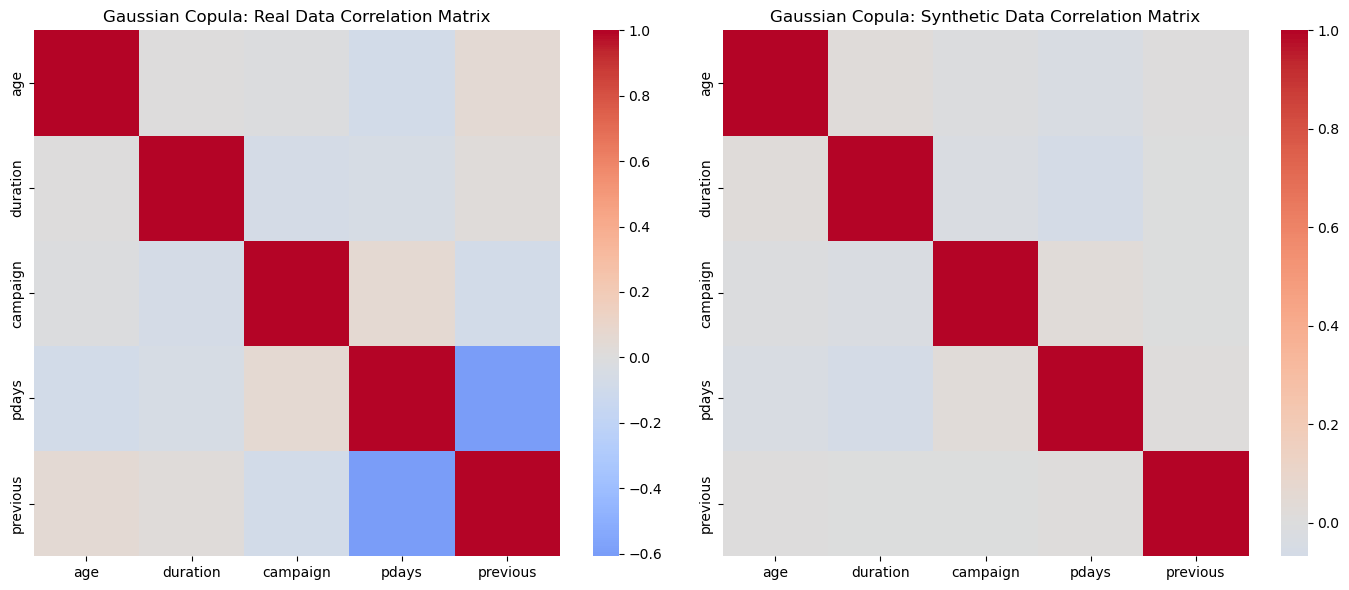

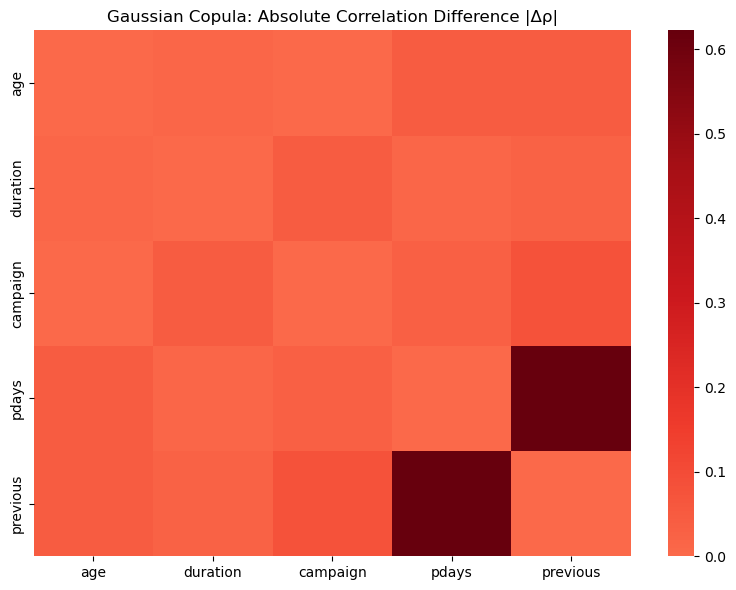

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != 'y']

real_df_gc = data[num_cols]
synth_df_gc = synthetic_data_gaussiancopula[num_cols]

# ------------------------------------
# Correlation heatmaps
# ------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    real_df_gc.corr(),
    cmap="coolwarm",
    center=0,
    ax=axes[0]
)
axes[0].set_title("Gaussian Copula: Real Data Correlation Matrix")

sns.heatmap(
    synth_df_gc.corr(),
    cmap="coolwarm",
    center=0,
    ax=axes[1]
)
axes[1].set_title("Gaussian Copula: Synthetic Data Correlation Matrix")

plt.tight_layout()
plt.show()

# ------------------------------------
# Absolute correlation difference
# ------------------------------------
diff_corr_gc = (real_df_gc.corr() - synth_df_gc.corr()).abs()

plt.figure(figsize=(8, 6))
sns.heatmap(
    diff_corr_gc,
    cmap="Reds",
    center=0
)
plt.title("Gaussian Copula: Absolute Correlation Difference |Δρ|")
plt.tight_layout()
plt.show()



## 4. TVAE Model

The **TVAE (Tabular Variational Autoencoder)** synthesizer is a deep learning–based generative model designed specifically for producing high-quality synthetic **tabular data**. It uses a **variational autoencoder (VAE)** architecture that encodes real data into a lower-dimensional latent space and then decodes samples from that space back into realistic synthetic records. Unlike traditional VAEs, TVAE handles a mix of **continuous and categorical features** by modeling them with appropriate likelihood functions, making it well-suited for datasets like the **Breast Cancer Wisconsin dataset**.


In [62]:
from sdv.single_table import TVAESynthesizer

# Train TVAE model
tvae = TVAESynthesizer(metadata)
tvae.fit(data)
synthetic_data_tvae = tvae.sample(10000)

# Diagnostic and quality check
diagnostic_report_tvae = run_diagnostic(data, synthetic_data_tvae, metadata)
quality_report_tvae = evaluate_quality(data, synthetic_data_tvae, metadata)


Generating report ...

(1/2) Evaluating Data Validity: |██████████| 16/16 [00:00<00:00, 1209.15it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<?, ?it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:01<00:00, 15.64it/s]|
Column Shapes Score: 85.76%

(2/2) Evaluating Column Pair Trends: |██████████| 120/120 [00:00<00:00, 137.10it/s]|
Column Pair Trends Score: 76.31%

Overall Score (Average): 81.03%



### 4.1 Kolmogorov-Smirnov (KS) Test


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 16/16 [00:01<00:00, 10.91it/s]|
Column Shapes Score: 85.76%

(2/2) Evaluating Column Pair Trends: |██████████| 120/120 [00:00<00:00, 201.74it/s]|
Column Pair Trends Score: 76.31%

Overall Score (Average): 81.03%

         Column        Metric     Score
0           age  KSComplement  0.975975
1           job  TVComplement  0.823956
2       marital  TVComplement  0.888571
3     education  TVComplement  0.934929
4       default  TVComplement  1.000000
5       housing  TVComplement  0.794528
6          loan  TVComplement  0.842272
7       contact  TVComplement  0.675473
8         month  TVComplement  0.625789
9   day_of_week  TVComplement  0.809930
10     duration  KSComplement  0.671480
11     campaign  KSComplement  0.897297
12        pdays  KSComplement  0.990472
13     previous  TVComplement  0.951613
14     poutcome  TVComplement  0.966199
15            y  TVComplement  0.873530


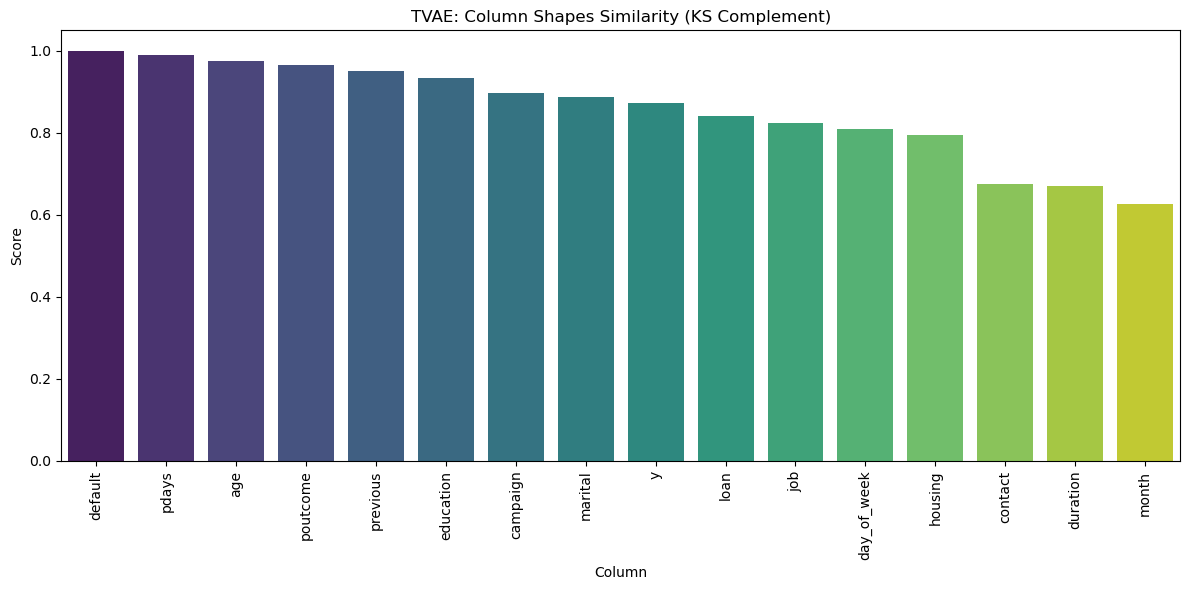

In [63]:
quality_report_tvae_ks = QualityReport()
quality_report_tvae_ks.generate(
    real_data=data,
    synthetic_data=synthetic_data_tvae,
    metadata=metadata.to_dict()  
)

details_tvae = quality_report_tvae_ks.get_details('Column Shapes')
print(details_tvae)

plt.figure(figsize=(12,6))
sns.barplot(
    x='Column', y='Score',
    data=details_tvae.sort_values('Score', ascending=False),
    palette='viridis'
)
plt.title('TVAE: Column Shapes Similarity (KS Complement)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### 4.2 Jensen-Shannon Divergence


        Feature  JS_Divergence
12        pdays       0.000000
13     previous       0.000000
14     poutcome       0.002028
0           age       0.007773
3     education       0.020142
9   day_of_week       0.039460
11     campaign       0.041306
2       marital       0.044256
1           job       0.056701
8         month       0.160518
10     duration       0.168770
5       housing       0.719381
7       contact       0.719801
6          loan       0.721113
15            y       0.722103
4       default       0.722387


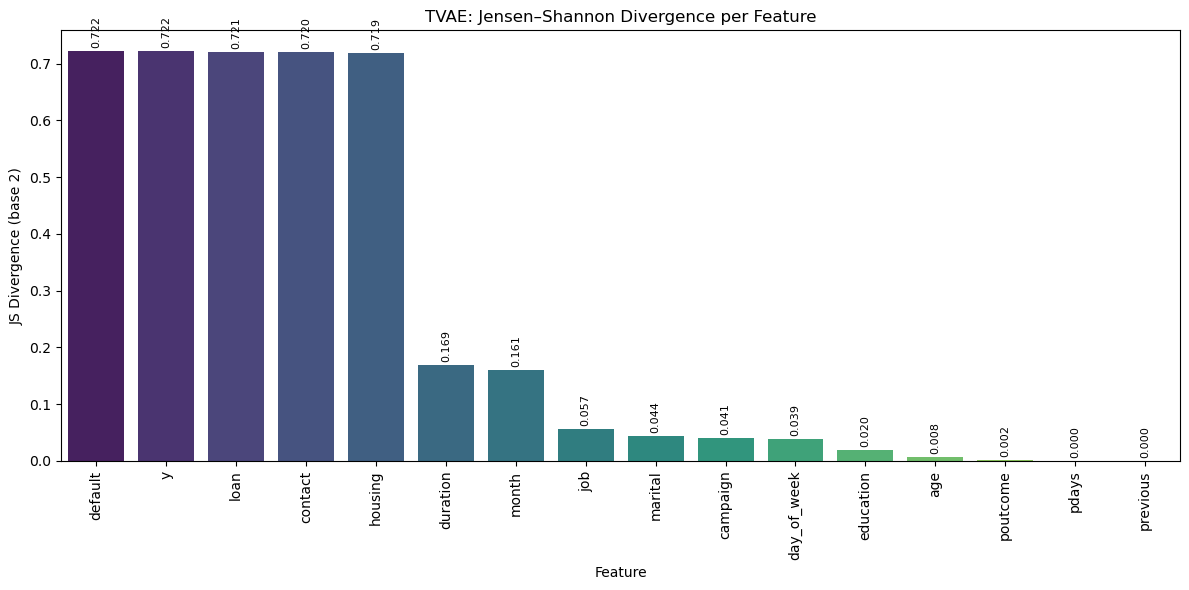

In [64]:
results_tvae_js = compute_js_divergence(data, synthetic_data_tvae, bins="fd", normalize=True)
print(results_tvae_js)

results_tvae_js_sorted = results_tvae_js.sort_values("JS_Divergence", ascending=False)
plt.figure(figsize=(12,6))
bars = sns.barplot(x="Feature", y="JS_Divergence", data=results_tvae_js_sorted, palette="viridis")

for bar in bars.patches:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.3f}",
             ha="center", va="bottom", fontsize=8, rotation=90)

plt.xticks(rotation=90)
plt.ylabel("JS Divergence (base 2)")
plt.title("TVAE: Jensen–Shannon Divergence per Feature")
plt.tight_layout()
plt.show()


### 4.3 Wasserstein Distance


In [65]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# 1️⃣ Keep only numeric columns (important)
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

real_num = data[num_cols].copy()
synthetic_num = synthetic_data_tvae[num_cols].copy()

# 2️⃣ Scale using MinMaxScaler (fit ONLY on real data)
scaler_tvae = MinMaxScaler()

real_scaled_tvae = pd.DataFrame(
    scaler_tvae.fit_transform(real_num),
    columns=num_cols
)

synthetic_scaled_tvae = pd.DataFrame(
    scaler_tvae.transform(synthetic_num),
    columns=num_cols
)

# 3️⃣ Compute Wasserstein distance
print("TVAE – Wasserstein Distance:")
for col in num_cols:
    dist = wasserstein_distance(
        real_scaled_tvae[col],
        synthetic_scaled_tvae[col]
    )
    print(f"{col}: {dist:.4f}")

TVAE – Wasserstein Distance:
age: 0.0067
duration: 0.0286
campaign: 0.0096
pdays: 0.0034
previous: 0.0088


### 4.4 Gower Distance


In [66]:
import gower
import numpy as np
import pandas as pd

X_real_tvae = data.drop('y', axis=1)
X_synth_tvae = synthetic_data_tvae.drop('y', axis=1) 

gower_real_tvae = 1 - gower.gower_matrix(X_real_tvae)
gower_synth_tvae = 1 - gower.gower_matrix(X_synth_tvae)
gower_combined_tvae = 1 - gower.gower_matrix(
    pd.concat([X_real_tvae, X_synth_tvae], axis=0)
)

real_upper_tvae = gower_real_tvae[np.triu_indices_from(gower_real_tvae, k=1)]
synth_upper_tvae = gower_synth_tvae[np.triu_indices_from(gower_synth_tvae, k=1)]

max_intra_real_tvae = np.max(real_upper_tvae)
avg_intra_real_tvae = np.mean(real_upper_tvae)

max_intra_synth_tvae = np.max(synth_upper_tvae)
avg_intra_synth_tvae = np.mean(synth_upper_tvae)

cross_flat_tvae = gower_combined_tvae.flatten()
max_cross_tvae = np.max(cross_flat_tvae)
avg_cross_tvae = np.mean(cross_flat_tvae)

print("TVAE – Gower Distance:")
print("Intra-set Similarity (Real):")
print(f"Max = {max_intra_real_tvae:.4f}, Avg = {avg_intra_real_tvae:.4f}\n")

print("Intra-set Similarity (Synthetic):")
print(f"Max = {max_intra_synth_tvae:.4f}, Avg = {avg_intra_synth_tvae:.4f}\n")

print("Cross-set Similarity (Real vs Synthetic):")
print(f"Max = {max_cross_tvae:.4f}, Avg = {avg_cross_tvae:.4f}")

TVAE – Gower Distance:
Intra-set Similarity (Real):
Max = 1.0000, Avg = 0.5377

Intra-set Similarity (Synthetic):
Max = 1.0000, Avg = 0.5811

Cross-set Similarity (Real vs Synthetic):
Max = 1.0000, Avg = 0.5636


### 4.5 t-SNE Visualization


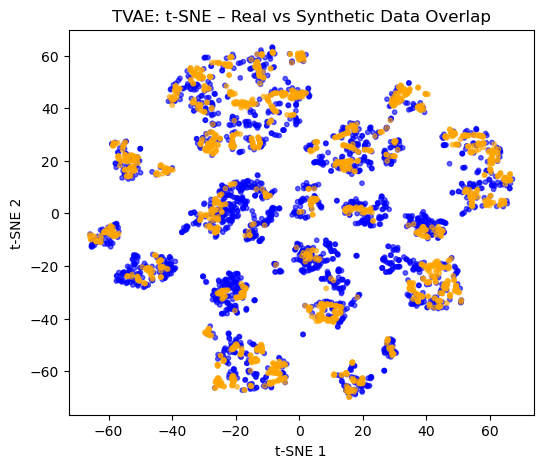

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE

# -----------------------------
# Settings
# -----------------------------
RANDOM_STATE = 42
N = 2000  # safe for t-SNE

np.random.seed(RANDOM_STATE)

# -----------------------------
# Subsample real & synthetic
# -----------------------------
real_tsne = data.sample(n=N, random_state=RANDOM_STATE).drop(columns=['y'])
synth_tsne = synthetic_data_tvae.sample(n=N, random_state=RANDOM_STATE).drop(columns=['y'])

# -----------------------------
# Identify columns
# -----------------------------
cat_cols = real_tsne.select_dtypes(include='object').columns
num_cols = real_tsne.select_dtypes(exclude='object').columns

# -----------------------------
# Impute missing values
# -----------------------------
cat_imputer = SimpleImputer(strategy='most_frequent')
num_imputer = SimpleImputer(strategy='median')

real_cat_imp = cat_imputer.fit_transform(real_tsne[cat_cols])
synth_cat_imp = cat_imputer.transform(synth_tsne[cat_cols])

real_num_imp = num_imputer.fit_transform(real_tsne[num_cols])
synth_num_imp = num_imputer.transform(synth_tsne[num_cols])

# -----------------------------
# Encode categorical features
# -----------------------------
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

real_cat_enc = encoder.fit_transform(real_cat_imp)
synth_cat_enc = encoder.transform(synth_cat_imp)

# -----------------------------
# Scale numerical features
# -----------------------------
scaler = StandardScaler()

real_num_scaled = scaler.fit_transform(real_num_imp)
synth_num_scaled = scaler.transform(synth_num_imp)

# -----------------------------
# Combine features
# -----------------------------
real_scaled = np.hstack([real_num_scaled, real_cat_enc])
synth_scaled = np.hstack([synth_num_scaled, synth_cat_enc])

combined = np.vstack([real_scaled, synth_scaled])

labels = np.array(
    ['Real'] * len(real_scaled) +
    ['Synthetic'] * len(synth_scaled)
)

# -----------------------------
# Run t-SNE
# -----------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=RANDOM_STATE
)

tsne_result = tsne.fit_transform(combined)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6, 5))

colors = np.where(labels == 'Real', 'blue', 'orange')

plt.scatter(
    tsne_result[:, 0],
    tsne_result[:, 1],
    c=colors,
    alpha=0.6,
    s=10
)

plt.title("TVAE: t-SNE – Real vs Synthetic Data Overlap")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

### 4.6 MMD (Maximum Mean Discrepancy)


In [68]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Select numeric columns
# -----------------------------
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != 'y']

real_num = data[num_cols].values
synthetic_num = synthetic_data_tvae[num_cols].values

# -----------------------------
# Standardize (fit on real only)
# -----------------------------
scaler = StandardScaler()
real_scaled = scaler.fit_transform(real_num)
synthetic_scaled = scaler.transform(synthetic_num)

# -----------------------------
# Linear-time RBF MMD
# -----------------------------
def linear_mmd(x, y, sigma=1.0, random_state=42):
    rng = np.random.default_rng(random_state)

    n = min(len(x), len(y))

    # FORCE EVEN SAMPLE SIZE
    n = n - (n % 2)

    # Randomly sample n points from each
    idx_x = rng.choice(len(x), n, replace=False)
    idx_y = rng.choice(len(y), n, replace=False)

    x = x[idx_x]
    y = y[idx_y]

    # Pair samples
    x1, x2 = x[0::2], x[1::2]
    y1, y2 = y[0::2], y[1::2]

    def rbf(a, b):
        return np.exp(-np.sum((a - b) ** 2, axis=1) / (2 * sigma ** 2))

    k_xx = np.mean(rbf(x1, x2))
    k_yy = np.mean(rbf(y1, y2))
    k_xy = np.mean(rbf(x1, y2))

    return k_xx + k_yy - 2 * k_xy

# -----------------------------
# Compute MMD
# -----------------------------
mmd_score_tvae = linear_mmd(real_scaled, synthetic_scaled, sigma=1.0)

print(f"TVAE – Linear MMD score: {mmd_score_tvae:.6f}")

TVAE – Linear MMD score: 0.033959


### 4.7 Cosine Similarity


In [69]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Ensure equal sample size (important)
n = min(len(real_scaled), len(synthetic_scaled))

real_scaled_tvae = real_scaled[:n]
synthetic_scaled_tvae = synthetic_scaled[:n]

# -----------------------------
# Compute cosine similarity
# -----------------------------
cross_sim_tvae = cosine_similarity(
    real_scaled_tvae,
    synthetic_scaled_tvae
)

avg_sim_tvae = np.mean(cross_sim_tvae)
max_sim_tvae = np.max(cross_sim_tvae)

print("TVAE – Sample-Level Cosine Similarity:")
print(f"Average cosine similarity: {avg_sim_tvae:.4f}")
print(f"Maximum cosine similarity: {max_sim_tvae:.4f}")


TVAE – Sample-Level Cosine Similarity:
Average cosine similarity: 0.1022
Maximum cosine similarity: 1.0000


### 4.9 Privacy Check


In [70]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# -----------------------------
# Reuse scaled numeric data
# -----------------------------
# These must already exist from TVAE MMD step:
# real_scaled
# synthetic_scaled

# Ensure equal dimensionality
assert real_scaled.shape[1] == synthetic_scaled.shape[1]

# Fit NN on REAL data
nn_tvae = NearestNeighbors(
    n_neighbors=1,
    metric='euclidean'
).fit(real_scaled)

# Query with SYNTHETIC data
distances_tvae, _ = nn_tvae.kneighbors(synthetic_scaled)

avg_nn_dist_tvae = distances_tvae.mean()
min_nn_dist_tvae = distances_tvae.min()

print("TVAE – Privacy Check (Numeric Features):")
print(f"Average Nearest Neighbor Distance (Synthetic → Real): {avg_nn_dist_tvae:.4f}")
print(f"Minimum Nearest Neighbor Distance (Worst Case): {min_nn_dist_tvae:.4f}")

TVAE – Privacy Check (Numeric Features):
Average Nearest Neighbor Distance (Synthetic → Real): 0.0461
Minimum Nearest Neighbor Distance (Worst Case): 0.0000


### 4.10 Bivariate Analysis


In [71]:
# Numeric columns EXCEPT target
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != 'y']

# Add y back explicitly
real_num_tvae = data[num_cols + ['y']].copy()
synth_num_tvae = synthetic_data_tvae[num_cols + ['y']].copy()

# Ensure alignment
synth_num_tvae = synth_num_tvae[real_num_tvae.columns]

# Run bivariate quality
corr_results_tvae, target_results_tvae = bivariate_quality_banking(
    real_df=real_num_tvae,
    synth_df=synth_num_tvae
)

# ------------------------------------
# Display results
# ------------------------------------
print("TVAE – Largest differences in pairwise correlations:")
print(corr_results_tvae.head(10))

print("\n================================")
print("TVAE – Features that differ most by target class:")
print(target_results_tvae.head(10))

TVAE – Largest differences in pairwise correlations:
      var_a     var_b  delta_corr
4  duration  campaign    0.338548
6  duration  previous    0.170924
5  duration     pdays    0.169935
9     pdays  previous    0.102390
8  campaign  previous    0.030327
0       age  duration    0.027782
1       age  campaign    0.026379
7  campaign     pdays    0.021012
3       age  previous    0.008479
2       age     pdays    0.000091

TVAE – Features that differ most by target class:
    feature  delta_wasserstein
0       age           0.055500
3     pdays           0.026167
2  campaign           0.022820
4  previous           0.019855
1  duration           0.016041


### 4.11 Multivariate Analysis


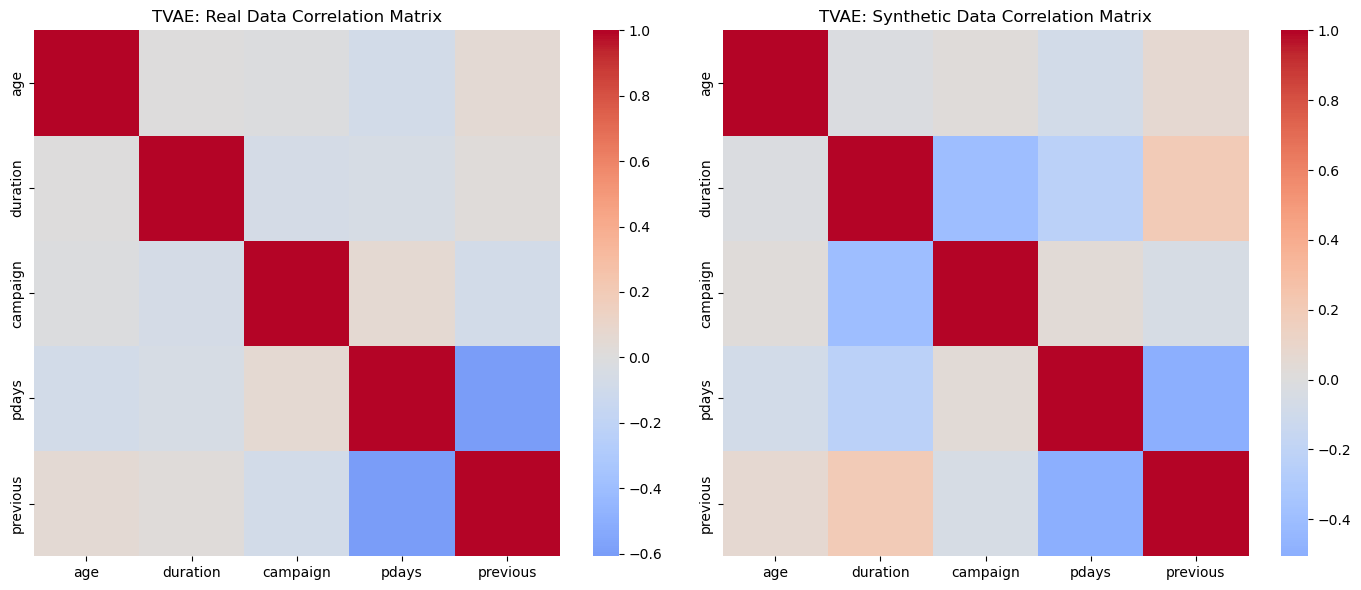

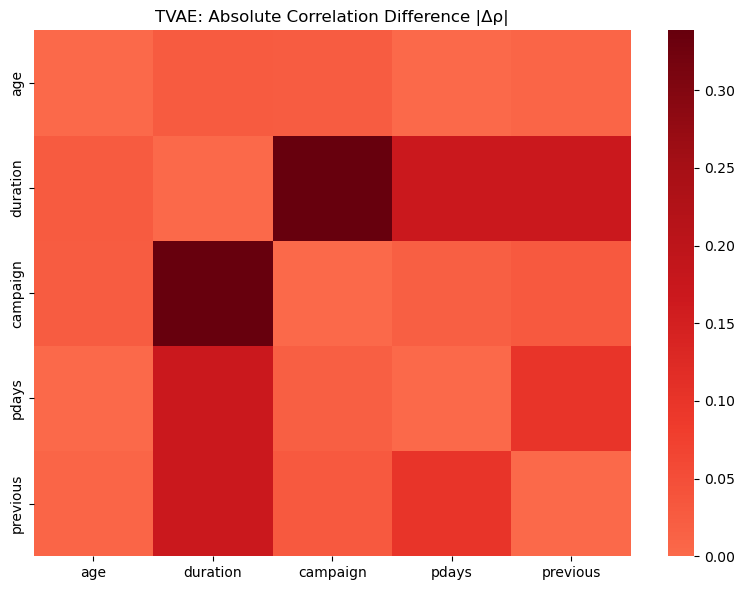

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = data.select_dtypes(include=['int64', 'float64']).columns
num_cols = [c for c in num_cols if c != 'y']

real_df_tvae = data[num_cols]
synth_df_tvae = synthetic_data_tvae[num_cols]

# ------------------------------------
# Correlation heatmaps
# ------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    real_df_tvae.corr(),
    cmap="coolwarm",
    center=0,
    ax=axes[0]
)
axes[0].set_title("TVAE: Real Data Correlation Matrix")

sns.heatmap(
    synth_df_tvae.corr(),
    cmap="coolwarm",
    center=0,
    ax=axes[1]
)
axes[1].set_title("TVAE: Synthetic Data Correlation Matrix")

plt.tight_layout()
plt.show()

# ------------------------------------
# Absolute correlation difference
# ------------------------------------
diff_corr_tvae = (real_df_tvae.corr() - synth_df_tvae.corr()).abs()

plt.figure(figsize=(8, 6))
sns.heatmap(
    diff_corr_tvae,
    cmap="Reds",
    center=0
)
plt.title("TVAE: Absolute Correlation Difference |Δρ|")
plt.tight_layout()
plt.show()

# Utility with 10 classifiers 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier


models = { 

    'LogReg': LogisticRegression(max_iter=5000, solver='liblinear', random_state=42),
    'SVM-RBF': SVC(kernel='rbf', probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'ExtraTrees':  ExtraTreesClassifier(random_state=42),
    'GradientBoost': GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "MLP": MLPClassifier(max_iter=2000, random_state=42),
}

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate_models(train_df, test_df, label_col, models, test_size=0.2, seed=42):
    # Split TRAIN df -> (train part only)  (we don’t need train_df's test split)
    X_train = train_df.drop(columns=[label_col])
    y_train = train_df[label_col]

    X_train, _, y_train, _ = train_test_split(
        X_train, y_train, test_size=test_size, random_state=seed, stratify=y_train
    )

    # Split TEST df -> (test part only)
    X_test = test_df.drop(columns=[label_col])
    y_test = test_df[label_col]

    _, X_test, _, y_test = train_test_split(
        X_test, y_test, test_size=test_size, random_state=seed, stratify=y_test
    )

    # Scale using TRAIN statistics only
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s  = scaler.transform(X_test)

    rows = []
    for name, clf in models.items():
        clf.fit(X_train_s, y_train)

        y_pred = clf.predict(X_test_s)

        # AUC needs probabilities (or decision_function); handle both safely
        if hasattr(clf, "predict_proba"):
            y_prob = clf.predict_proba(X_test_s)[:, 1]
        elif hasattr(clf, "decision_function"):
            scores = clf.decision_function(X_test_s)
            # convert to 0-1-ish range (not perfect prob, but works for AUC)
            y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
        else:
            y_prob = None

        acc = accuracy_score(y_test, y_pred)
        f1  = f1_score(y_test, y_pred)

        auc = roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan")

        rows.append({"Model": name, "Accuracy": acc, "F1": f1, "AUC": auc})

    return pd.DataFrame(rows).sort_values(by="AUC", ascending=False)

## Guassian Copula 

In [ ]:
label_col = "diagnosis"

tstr_results_gc = evaluate_models(
    train_df=synthetic_data_gaussiancopula,
    test_df=cancer_data,
    label_col=label_col,
    models=models
)

print("Gaussian Copula - TSTR (Train Synth, Test Real)")
display(tstr_results_gc)

print('==================================================')

trtr_results = evaluate_models(
    train_df=cancer_data,
    test_df=cancer_data,
    label_col=label_col,
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)


print('==================================================')

comparison = trtr_results.merge(
    tstr_results_gc, on="Model", suffixes=("_TRTR", "_TSTR")
)

comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
comparison = comparison.sort_values("AUC_Drop", ascending=False)

display(comparison)


Gaussian Copula - TSTR (Train Synth, Test Real)


,Model,Accuracy,F1,AUC
0,LogReg,0.868421,0.782609,0.983796
3,NaiveBayes,0.885965,0.826667,0.980489
6,ExtraTrees,0.912281,0.864865,0.977017
1,SVM-RBF,0.877193,0.800000,0.967593
5,RandomForest,0.894737,0.833333,0.966270
8,AdaBoost,0.894737,0.837838,0.959491
7,GradientBoost,0.877193,0.810811,0.958664
2,KNN,0.877193,0.810811,0.899140
9,MLP,0.710526,0.611765,0.816799
4,DecisionTree,0.754386,0.688889,0.750992


TRTR (Train Real, Test Real)


,Model,Accuracy,F1,AUC
6,ExtraTrees,0.973684,0.962963,0.998843
0,LogReg,0.973684,0.963855,0.996032
7,GradientBoost,0.964912,0.950000,0.994709
1,SVM-RBF,0.973684,0.962963,0.994709
9,MLP,0.964912,0.950000,0.993717
5,RandomForest,0.973684,0.962963,0.992890
3,NaiveBayes,0.921053,0.888889,0.989087
8,AdaBoost,0.982456,0.975610,0.984127
2,KNN,0.956140,0.938272,0.982308
4,DecisionTree,0.929825,0.904762,0.924603


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop
4,MLP,0.964912,0.950000,0.993717,0.710526,0.611765,0.816799,0.176918
9,DecisionTree,0.929825,0.904762,0.924603,0.754386,0.688889,0.750992,0.173611
8,KNN,0.956140,0.938272,0.982308,0.877193,0.810811,0.899140,0.083168
2,GradientBoost,0.964912,0.950000,0.994709,0.877193,0.810811,0.958664,0.036045
3,SVM-RBF,0.973684,0.962963,0.994709,0.877193,0.800000,0.967593,0.027116
5,RandomForest,0.973684,0.962963,0.992890,0.894737,0.833333,0.966270,0.026620
7,AdaBoost,0.982456,0.975610,0.984127,0.894737,0.837838,0.959491,0.024636
0,ExtraTrees,0.973684,0.962963,0.998843,0.912281,0.864865,0.977017,0.021825
1,LogReg,0.973684,0.963855,0.996032,0.868421,0.782609,0.983796,0.012235
6,NaiveBayes,0.921053,0.888889,0.989087,0.885965,0.826667,0.980489,0.008598


In [ ]:
import matplotlib.pyplot as plt 

def plot_trtr_vs_tstr(trtr_results, tstr_results, metric='AUC'):
    df = trtr_results[['Model', metric]].merge(
        tstr_results[['Model', metric]], on='Model', suffixes = ("_TRTR", "_TSTR"))
    
    df['Drop'] = df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    df = df.sort_values('Drop', ascending = False)

    x = np.arange(len(df))
    w = 0.38

    plt.figure(figsize=(12,5))
    plt.bar(x - w/2, df[f"{metric}_TRTR"], w, label=f"{metric} TRTR")
    plt.bar(x + w/2, df[f"{metric}_TSTR"], w, label=f"{metric} TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_auc_drop(comparison_df):
    df = comparison_df.sort_values("AUC_Drop", ascending=False)

    x = np.arange(len(df))
    plt.figure(figsize=(12,5))
    plt.bar(x, df["AUC_Drop"])
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel("AUC drop (TRTR - TSTR)")
    plt.title("AUC Drop from TRTR to TSTR")
    plt.tight_layout()
    plt.show()   


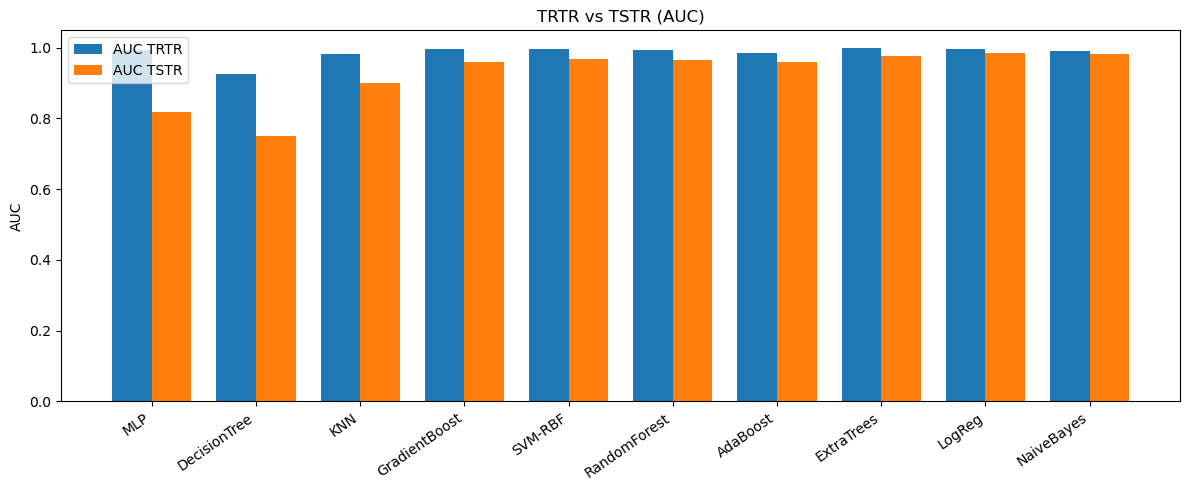

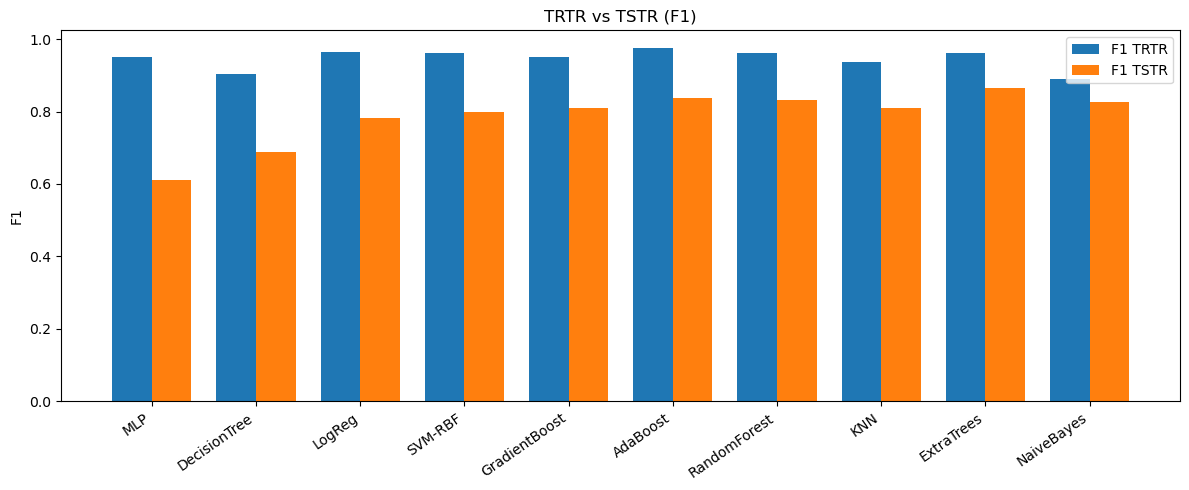

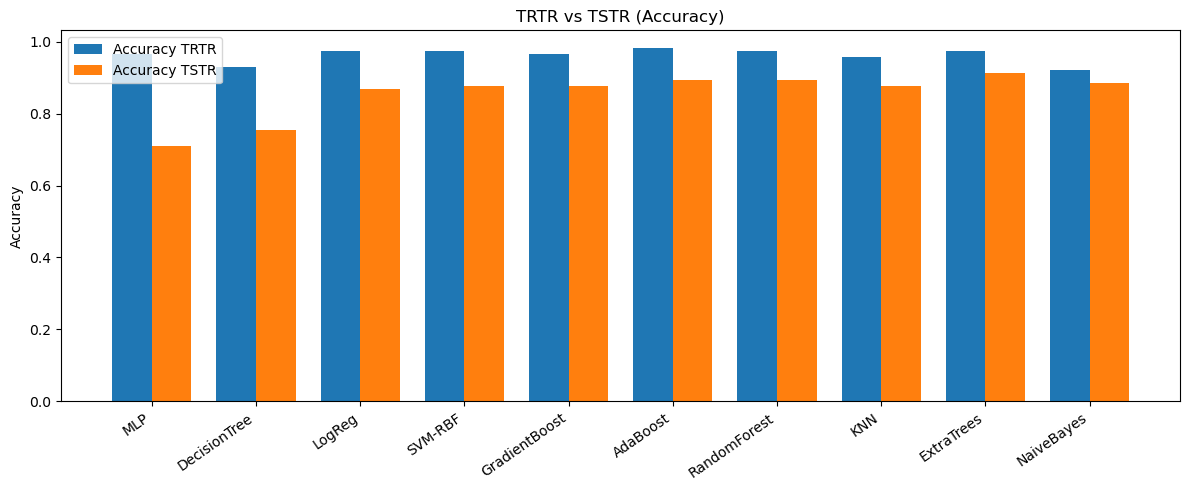

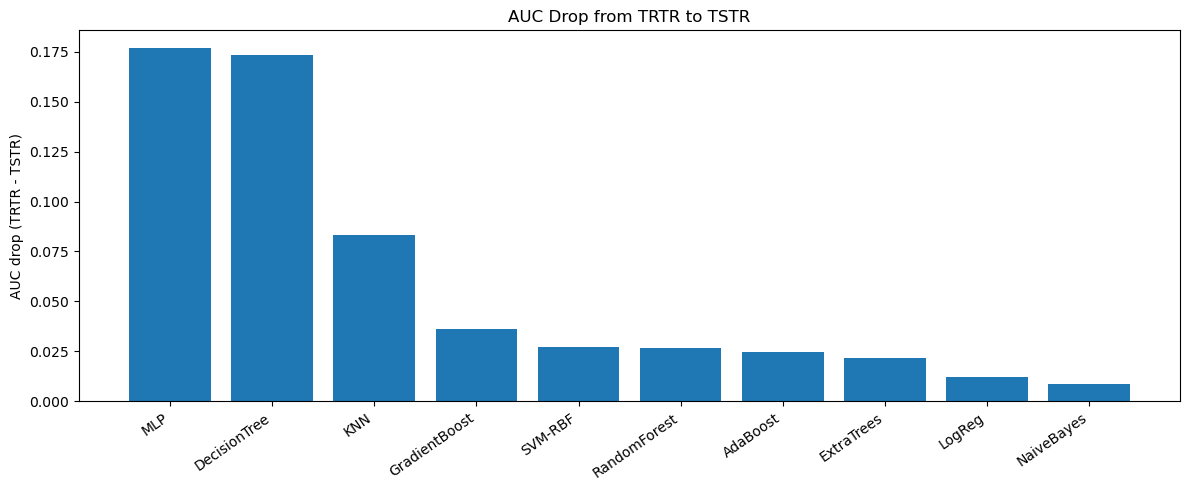

In [ ]:
plot_trtr_vs_tstr(trtr_results, tstr_results_gc, metric="AUC")
plot_trtr_vs_tstr(trtr_results, tstr_results_gc, metric="F1")
plot_trtr_vs_tstr(trtr_results, tstr_results_gc, metric="Accuracy")

plot_auc_drop(comparison)

## CTGAN

In [ ]:
label_col = "diagnosis"

tstr_results_ctgan = evaluate_models(
    train_df=synthetic_data_ctgan,
    test_df=cancer_data,
    label_col=label_col,
    models=models
)

print("CTGAN - TSTR (Train Synth, Test Real)")
display(tstr_results_ctgan)

print('==================================================')

trtr_results = evaluate_models(
    train_df=cancer_data,
    test_df=cancer_data,
    label_col=label_col,
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)


print('==================================================')

comparison = trtr_results.merge(
    tstr_results_ctgan, on="Model", suffixes=("_TRTR", "_TSTR")
)

comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
comparison = comparison.sort_values("AUC_Drop", ascending=False)

display(comparison)

CTGAN - TSTR (Train Synth, Test Real)


,Model,Accuracy,F1,AUC
6,ExtraTrees,0.745614,0.539683,0.796462
5,RandomForest,0.657895,0.315789,0.721561
3,NaiveBayes,0.710526,0.602410,0.720899
0,LogReg,0.710526,0.535211,0.720569
9,MLP,0.692982,0.444444,0.711310
1,SVM-RBF,0.701754,0.484848,0.709656
7,GradientBoost,0.657895,0.315789,0.606812
8,AdaBoost,0.535088,0.311688,0.532077
2,KNN,0.596491,0.378378,0.514716
4,DecisionTree,0.517544,0.395604,0.499008


TRTR (Train Real, Test Real)


,Model,Accuracy,F1,AUC
6,ExtraTrees,0.973684,0.962963,0.998843
0,LogReg,0.973684,0.963855,0.996032
7,GradientBoost,0.964912,0.950000,0.994709
1,SVM-RBF,0.973684,0.962963,0.994709
9,MLP,0.964912,0.950000,0.993717
5,RandomForest,0.973684,0.962963,0.992890
3,NaiveBayes,0.921053,0.888889,0.989087
8,AdaBoost,0.982456,0.975610,0.984127
2,KNN,0.956140,0.938272,0.982308
4,DecisionTree,0.929825,0.904762,0.924603


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop
8,KNN,0.956140,0.938272,0.982308,0.596491,0.378378,0.514716,0.467593
7,AdaBoost,0.982456,0.975610,0.984127,0.535088,0.311688,0.532077,0.452050
9,DecisionTree,0.929825,0.904762,0.924603,0.517544,0.395604,0.499008,0.425595
2,GradientBoost,0.964912,0.950000,0.994709,0.657895,0.315789,0.606812,0.387897
3,SVM-RBF,0.973684,0.962963,0.994709,0.701754,0.484848,0.709656,0.285053
4,MLP,0.964912,0.950000,0.993717,0.692982,0.444444,0.711310,0.282407
1,LogReg,0.973684,0.963855,0.996032,0.710526,0.535211,0.720569,0.275463
5,RandomForest,0.973684,0.962963,0.992890,0.657895,0.315789,0.721561,0.271329
6,NaiveBayes,0.921053,0.888889,0.989087,0.710526,0.602410,0.720899,0.268188
0,ExtraTrees,0.973684,0.962963,0.998843,0.745614,0.539683,0.796462,0.202381


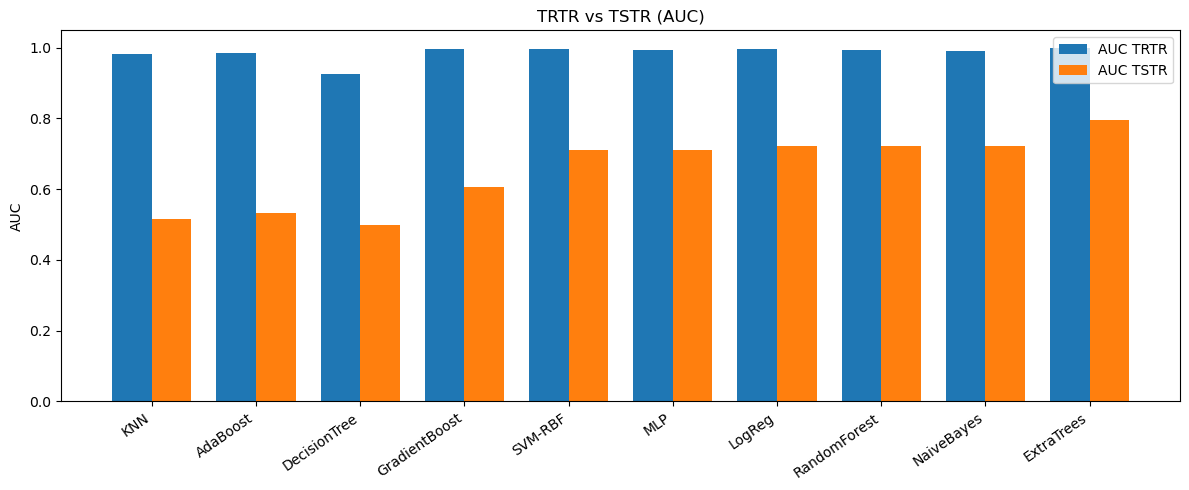

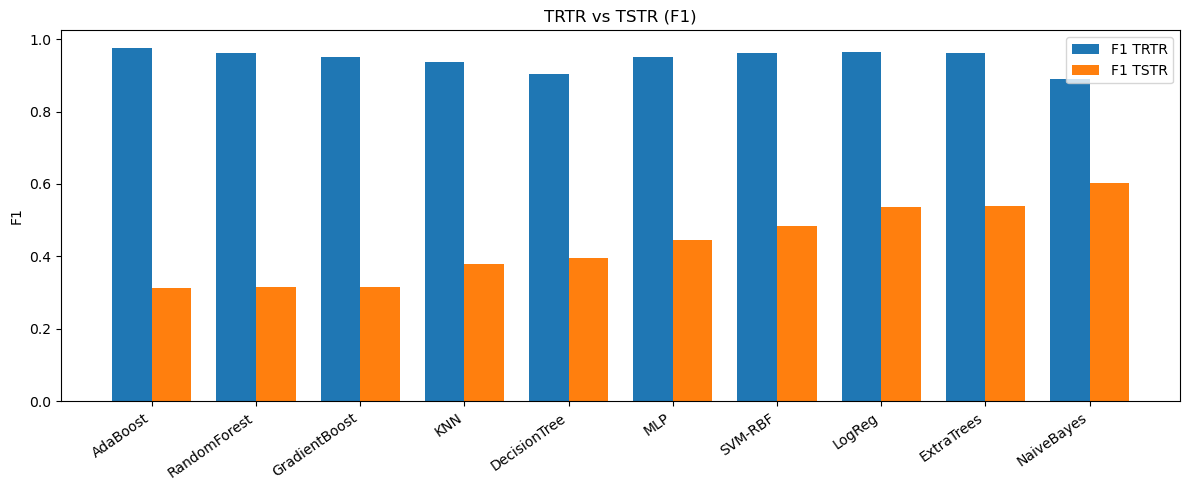

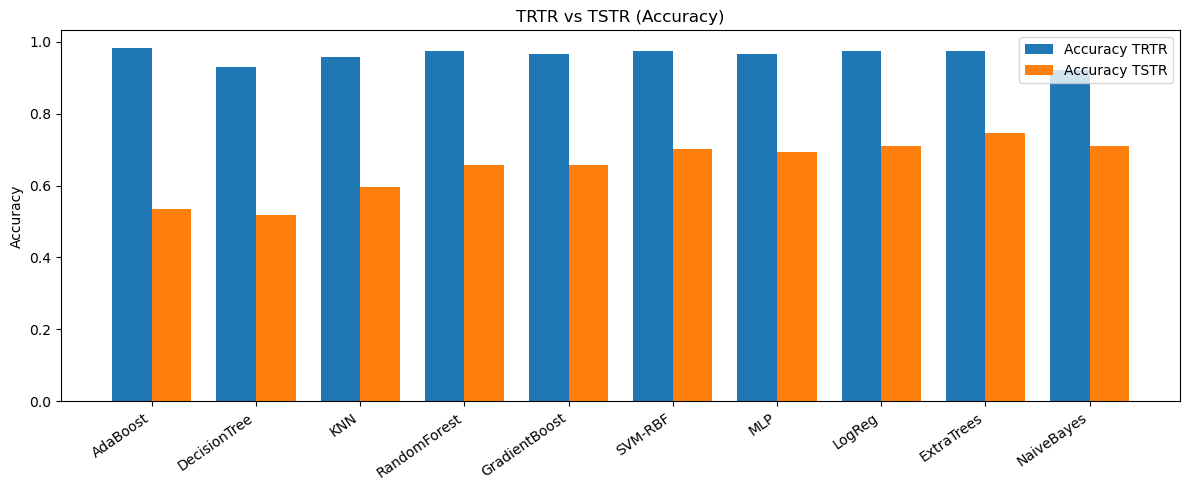

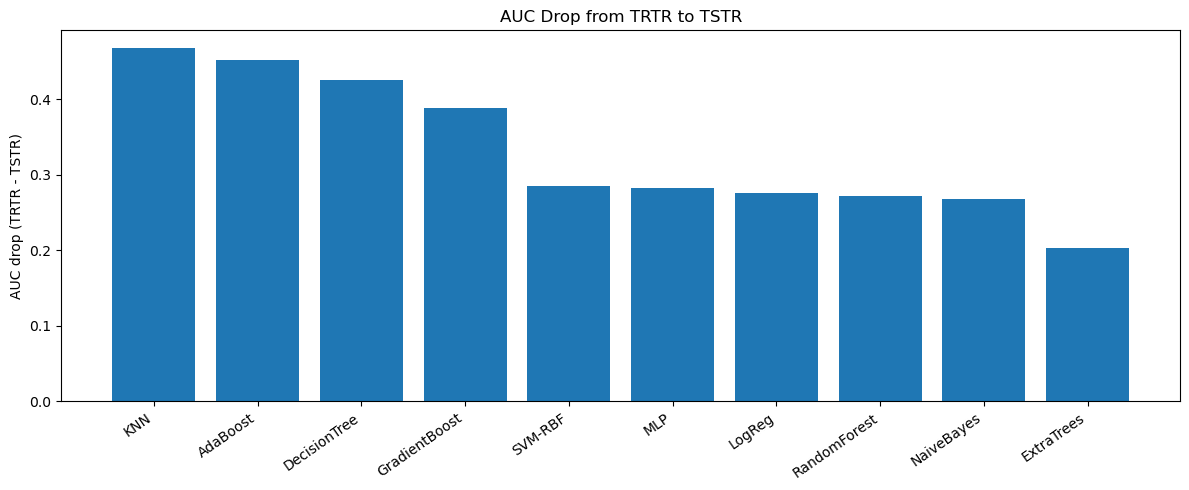

In [ ]:
plot_trtr_vs_tstr(trtr_results, tstr_results_ctgan, metric="AUC")
plot_trtr_vs_tstr(trtr_results, tstr_results_ctgan, metric="F1")
plot_trtr_vs_tstr(trtr_results, tstr_results_ctgan, metric="Accuracy")

plot_auc_drop(comparison)

## Copula GAN

In [ ]:
label_col = "diagnosis"

tstr_results_copulagan = evaluate_models(
    train_df=synthetic_data_copulagan,
    test_df=cancer_data,
    label_col=label_col,
    models=models
)

print("CopulaGAN - TSTR (Train Synth, Test Real)")
display(tstr_results_copulagan)

print('==================================================')

trtr_results = evaluate_models(
    train_df=cancer_data,
    test_df=cancer_data,
    label_col=label_col,
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)


print('==================================================')

comparison = trtr_results.merge(
    tstr_results_ctgan, on="Model", suffixes=("_TRTR", "_TSTR")
)

comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
comparison = comparison.sort_values("AUC_Drop", ascending=False)

display(comparison)

CopulaGAN - TSTR (Train Synth, Test Real)


,Model,Accuracy,F1,AUC
3,NaiveBayes,0.885965,0.843373,0.952712
0,LogReg,0.824561,0.761905,0.917659
1,SVM-RBF,0.824561,0.782609,0.912864
9,MLP,0.780702,0.752475,0.894180
5,RandomForest,0.780702,0.698795,0.863591
6,ExtraTrees,0.771930,0.690476,0.849702
7,GradientBoost,0.780702,0.712644,0.818452
2,KNN,0.736842,0.558824,0.803737
8,AdaBoost,0.684211,0.647059,0.768519
4,DecisionTree,0.719298,0.567568,0.673611


TRTR (Train Real, Test Real)


,Model,Accuracy,F1,AUC
6,ExtraTrees,0.973684,0.962963,0.998843
0,LogReg,0.973684,0.963855,0.996032
7,GradientBoost,0.964912,0.950000,0.994709
1,SVM-RBF,0.973684,0.962963,0.994709
9,MLP,0.964912,0.950000,0.993717
5,RandomForest,0.973684,0.962963,0.992890
3,NaiveBayes,0.921053,0.888889,0.989087
8,AdaBoost,0.982456,0.975610,0.984127
2,KNN,0.956140,0.938272,0.982308
4,DecisionTree,0.929825,0.904762,0.924603


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop
8,KNN,0.956140,0.938272,0.982308,0.596491,0.378378,0.514716,0.467593
7,AdaBoost,0.982456,0.975610,0.984127,0.535088,0.311688,0.532077,0.452050
9,DecisionTree,0.929825,0.904762,0.924603,0.517544,0.395604,0.499008,0.425595
2,GradientBoost,0.964912,0.950000,0.994709,0.657895,0.315789,0.606812,0.387897
3,SVM-RBF,0.973684,0.962963,0.994709,0.701754,0.484848,0.709656,0.285053
4,MLP,0.964912,0.950000,0.993717,0.692982,0.444444,0.711310,0.282407
1,LogReg,0.973684,0.963855,0.996032,0.710526,0.535211,0.720569,0.275463
5,RandomForest,0.973684,0.962963,0.992890,0.657895,0.315789,0.721561,0.271329
6,NaiveBayes,0.921053,0.888889,0.989087,0.710526,0.602410,0.720899,0.268188
0,ExtraTrees,0.973684,0.962963,0.998843,0.745614,0.539683,0.796462,0.202381


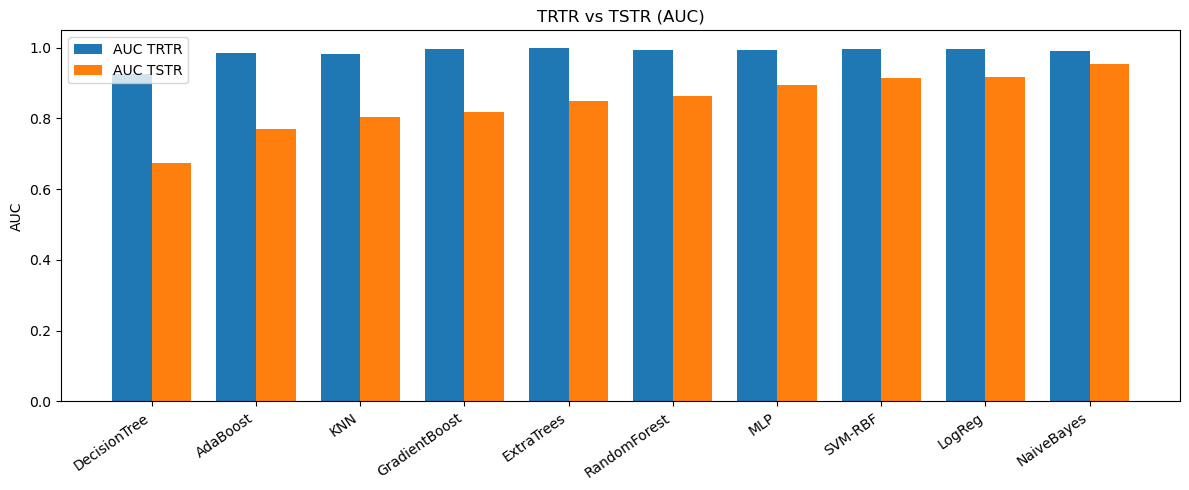

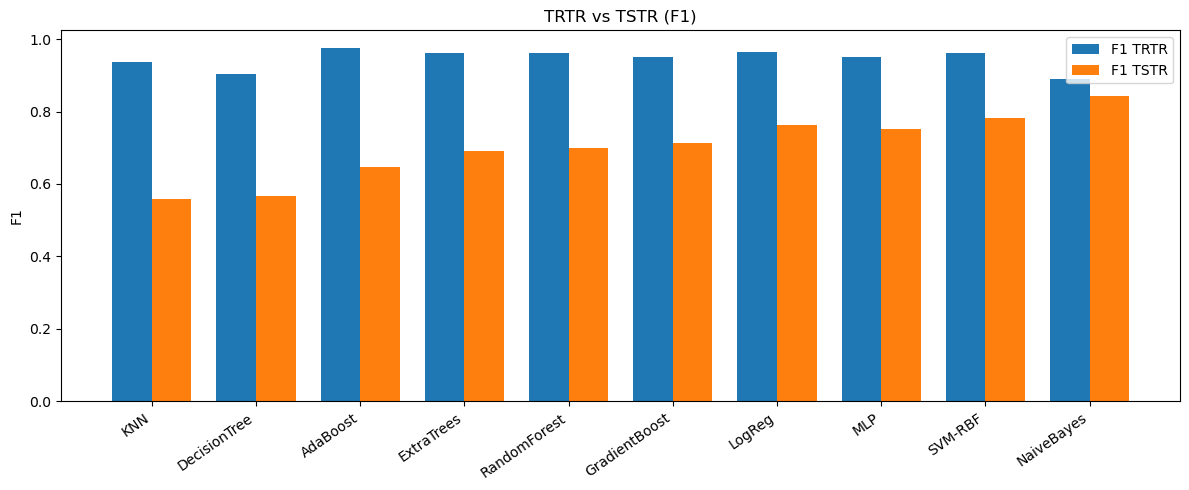

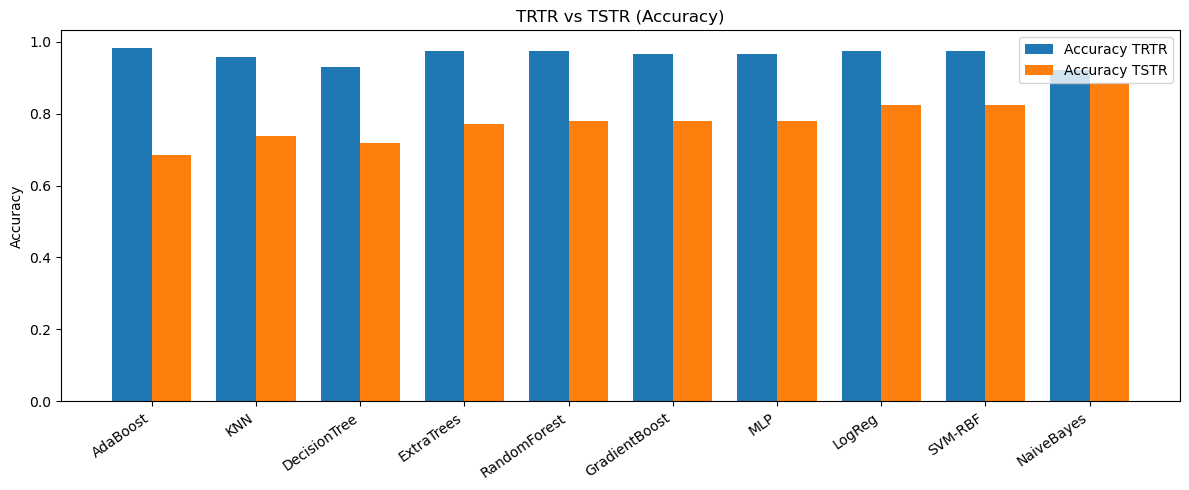

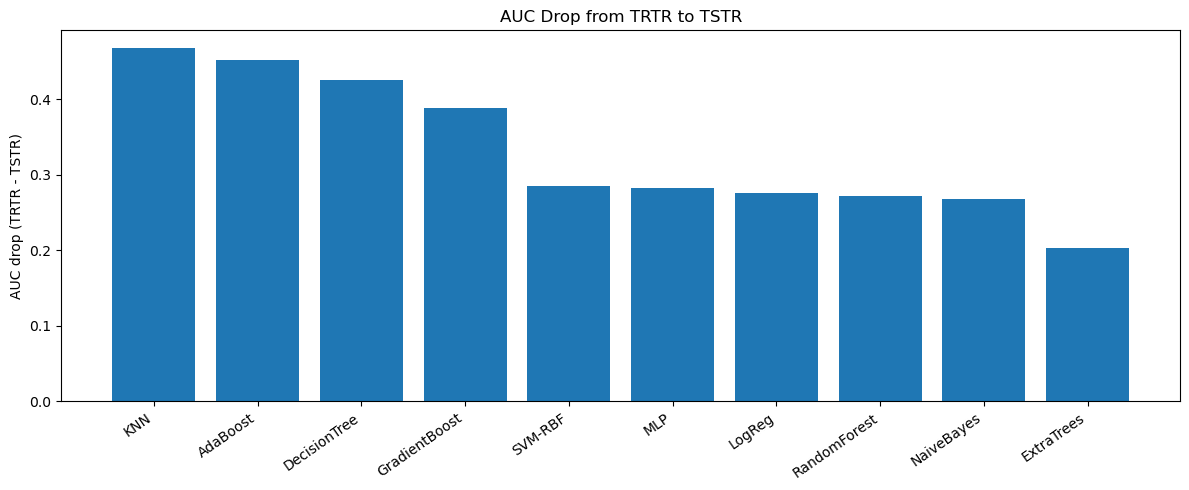

In [ ]:
plot_trtr_vs_tstr(trtr_results, tstr_results_copulagan, metric="AUC")
plot_trtr_vs_tstr(trtr_results, tstr_results_copulagan, metric="F1")
plot_trtr_vs_tstr(trtr_results, tstr_results_copulagan, metric="Accuracy")

plot_auc_drop(comparison)

## TVAE

In [ ]:
label_col = "diagnosis"

tstr_results_tvae = evaluate_models(
    train_df=synthetic_data_tvae,
    test_df=cancer_data,
    label_col=label_col,
    models=models
)

print("TVAE - TSTR (Train Synth, Test Real)")
display(tstr_results_tvae)

print('==================================================')

trtr_results = evaluate_models(
    train_df=cancer_data,
    test_df=cancer_data,
    label_col=label_col,
    models=models
)

print("TRTR (Train Real, Test Real)")
display(trtr_results)


print('==================================================')

comparison = trtr_results.merge(
    tstr_results_ctgan, on="Model", suffixes=("_TRTR", "_TSTR")
)

comparison["AUC_Drop"] = comparison["AUC_TRTR"] - comparison["AUC_TSTR"]
comparison = comparison.sort_values("AUC_Drop", ascending=False)

display(comparison)

TVAE - TSTR (Train Synth, Test Real)


,Model,Accuracy,F1,AUC
9,MLP,0.991228,0.988235,1.000000
0,LogReg,0.991228,0.988235,0.999008
8,AdaBoost,0.973684,0.964706,0.999008
7,GradientBoost,0.991228,0.988235,0.997685
6,ExtraTrees,0.964912,0.952381,0.996528
5,RandomForest,0.982456,0.976744,0.996362
2,KNN,0.956140,0.936709,0.995701
1,SVM-RBF,0.921053,0.901099,0.993056
3,NaiveBayes,0.929825,0.909091,0.987103
4,DecisionTree,0.894737,0.850000,0.876984


TRTR (Train Real, Test Real)


,Model,Accuracy,F1,AUC
6,ExtraTrees,0.973684,0.962963,0.998843
0,LogReg,0.973684,0.963855,0.996032
7,GradientBoost,0.964912,0.950000,0.994709
1,SVM-RBF,0.973684,0.962963,0.994709
9,MLP,0.964912,0.950000,0.993717
5,RandomForest,0.973684,0.962963,0.992890
3,NaiveBayes,0.921053,0.888889,0.989087
8,AdaBoost,0.982456,0.975610,0.984127
2,KNN,0.956140,0.938272,0.982308
4,DecisionTree,0.929825,0.904762,0.924603


,Model,Accuracy_TRTR,F1_TRTR,AUC_TRTR,Accuracy_TSTR,F1_TSTR,AUC_TSTR,AUC_Drop
8,KNN,0.956140,0.938272,0.982308,0.596491,0.378378,0.514716,0.467593
7,AdaBoost,0.982456,0.975610,0.984127,0.535088,0.311688,0.532077,0.452050
9,DecisionTree,0.929825,0.904762,0.924603,0.517544,0.395604,0.499008,0.425595
2,GradientBoost,0.964912,0.950000,0.994709,0.657895,0.315789,0.606812,0.387897
3,SVM-RBF,0.973684,0.962963,0.994709,0.701754,0.484848,0.709656,0.285053
4,MLP,0.964912,0.950000,0.993717,0.692982,0.444444,0.711310,0.282407
1,LogReg,0.973684,0.963855,0.996032,0.710526,0.535211,0.720569,0.275463
5,RandomForest,0.973684,0.962963,0.992890,0.657895,0.315789,0.721561,0.271329
6,NaiveBayes,0.921053,0.888889,0.989087,0.710526,0.602410,0.720899,0.268188
0,ExtraTrees,0.973684,0.962963,0.998843,0.745614,0.539683,0.796462,0.202381


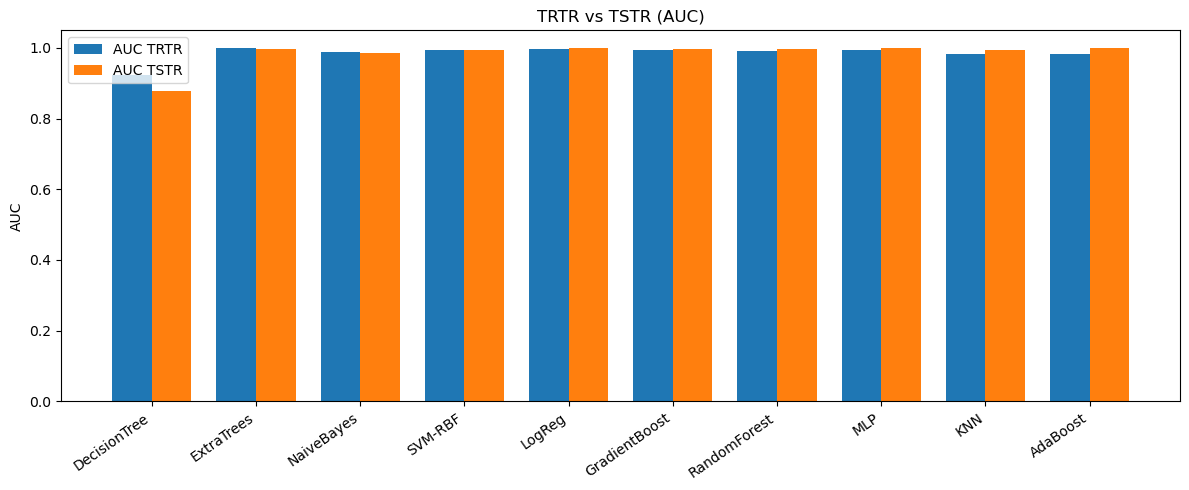

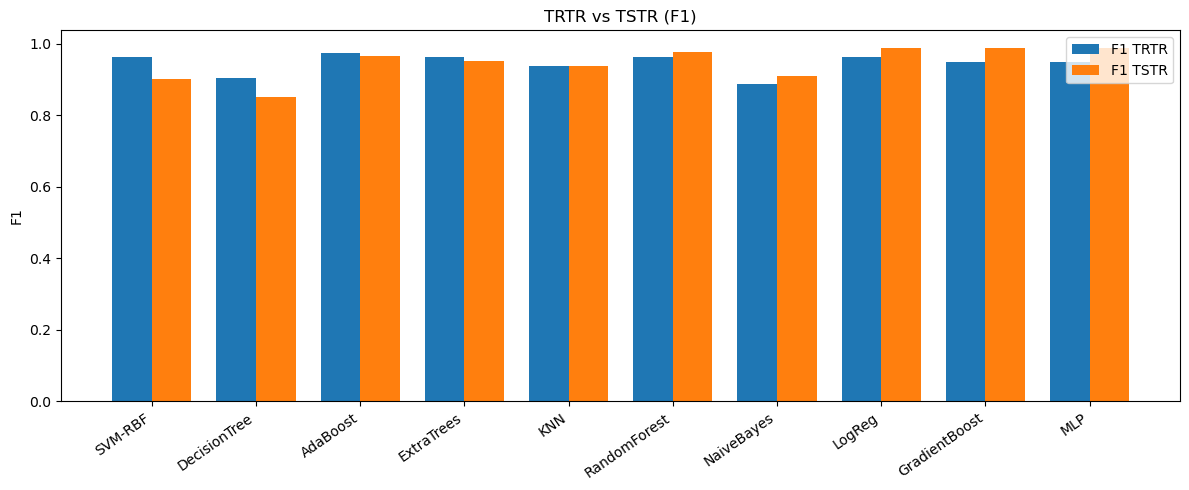

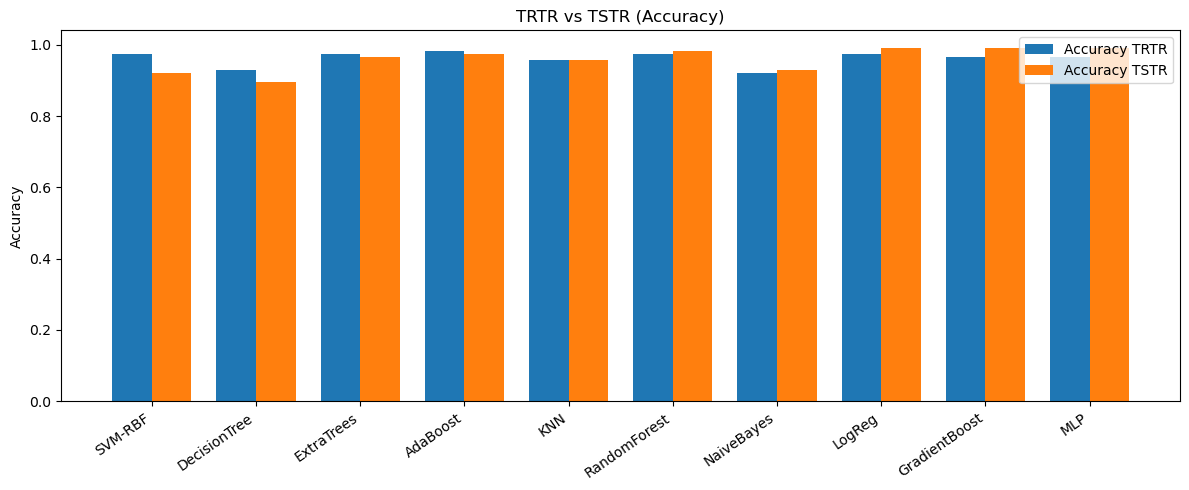

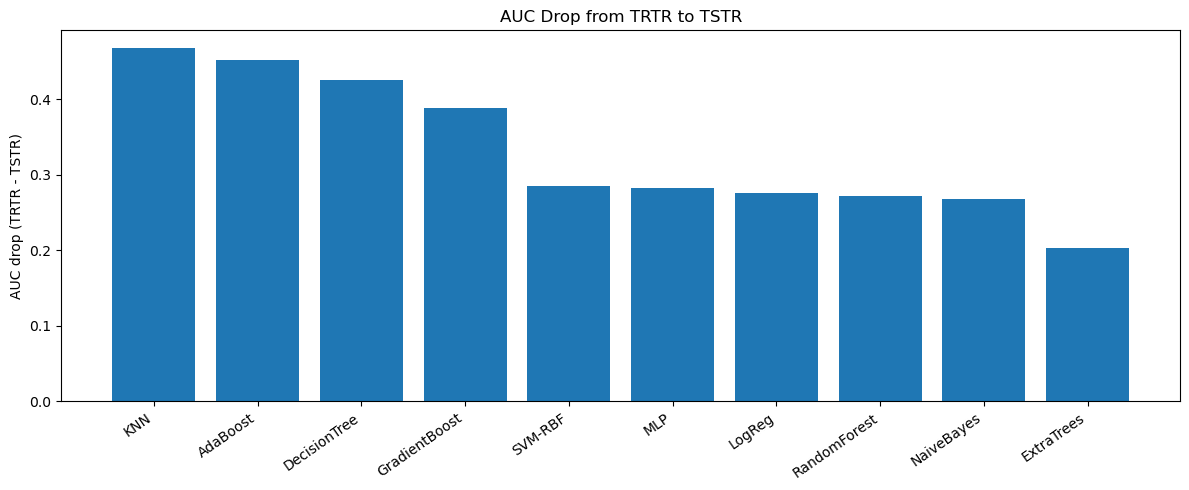

In [ ]:
plot_trtr_vs_tstr(trtr_results, tstr_results_tvae, metric="AUC")
plot_trtr_vs_tstr(trtr_results, tstr_results_tvae, metric="F1")
plot_trtr_vs_tstr(trtr_results, tstr_results_tvae, metric="Accuracy")

plot_auc_drop(comparison)

In [ ]:
def plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results,
    generator_name,
    ncols=5
):
    metrics = ["Accuracy", "F1", "AUC"]
    x = np.arange(len(metrics))

    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models = [m for m in trtr.index if m in tstr.index]

    n = len(models)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(22, 9),
        dpi=150,
        constrained_layout=True
    )
    axes = np.array(axes).reshape(-1)

    for i, m in enumerate(models):
        ax = axes[i]
        a = trtr.loc[m].values.astype(float)
        b = tstr.loc[m].values.astype(float)

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="o", label="TSTR")
        ax.fill_between(x, b, a, alpha=0.2)

        ax.set_title(m, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        ax.set_ylim(0, 1.05)

        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="lower left")

    # Hide unused subplots
    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{generator_name} — TRTR vs TSTR per classifier (Accuracy, F1, AUC)\n"
        f"Shaded area = generalisation gap (TRTR − TSTR)",
        fontsize=14
    )

    plt.show()

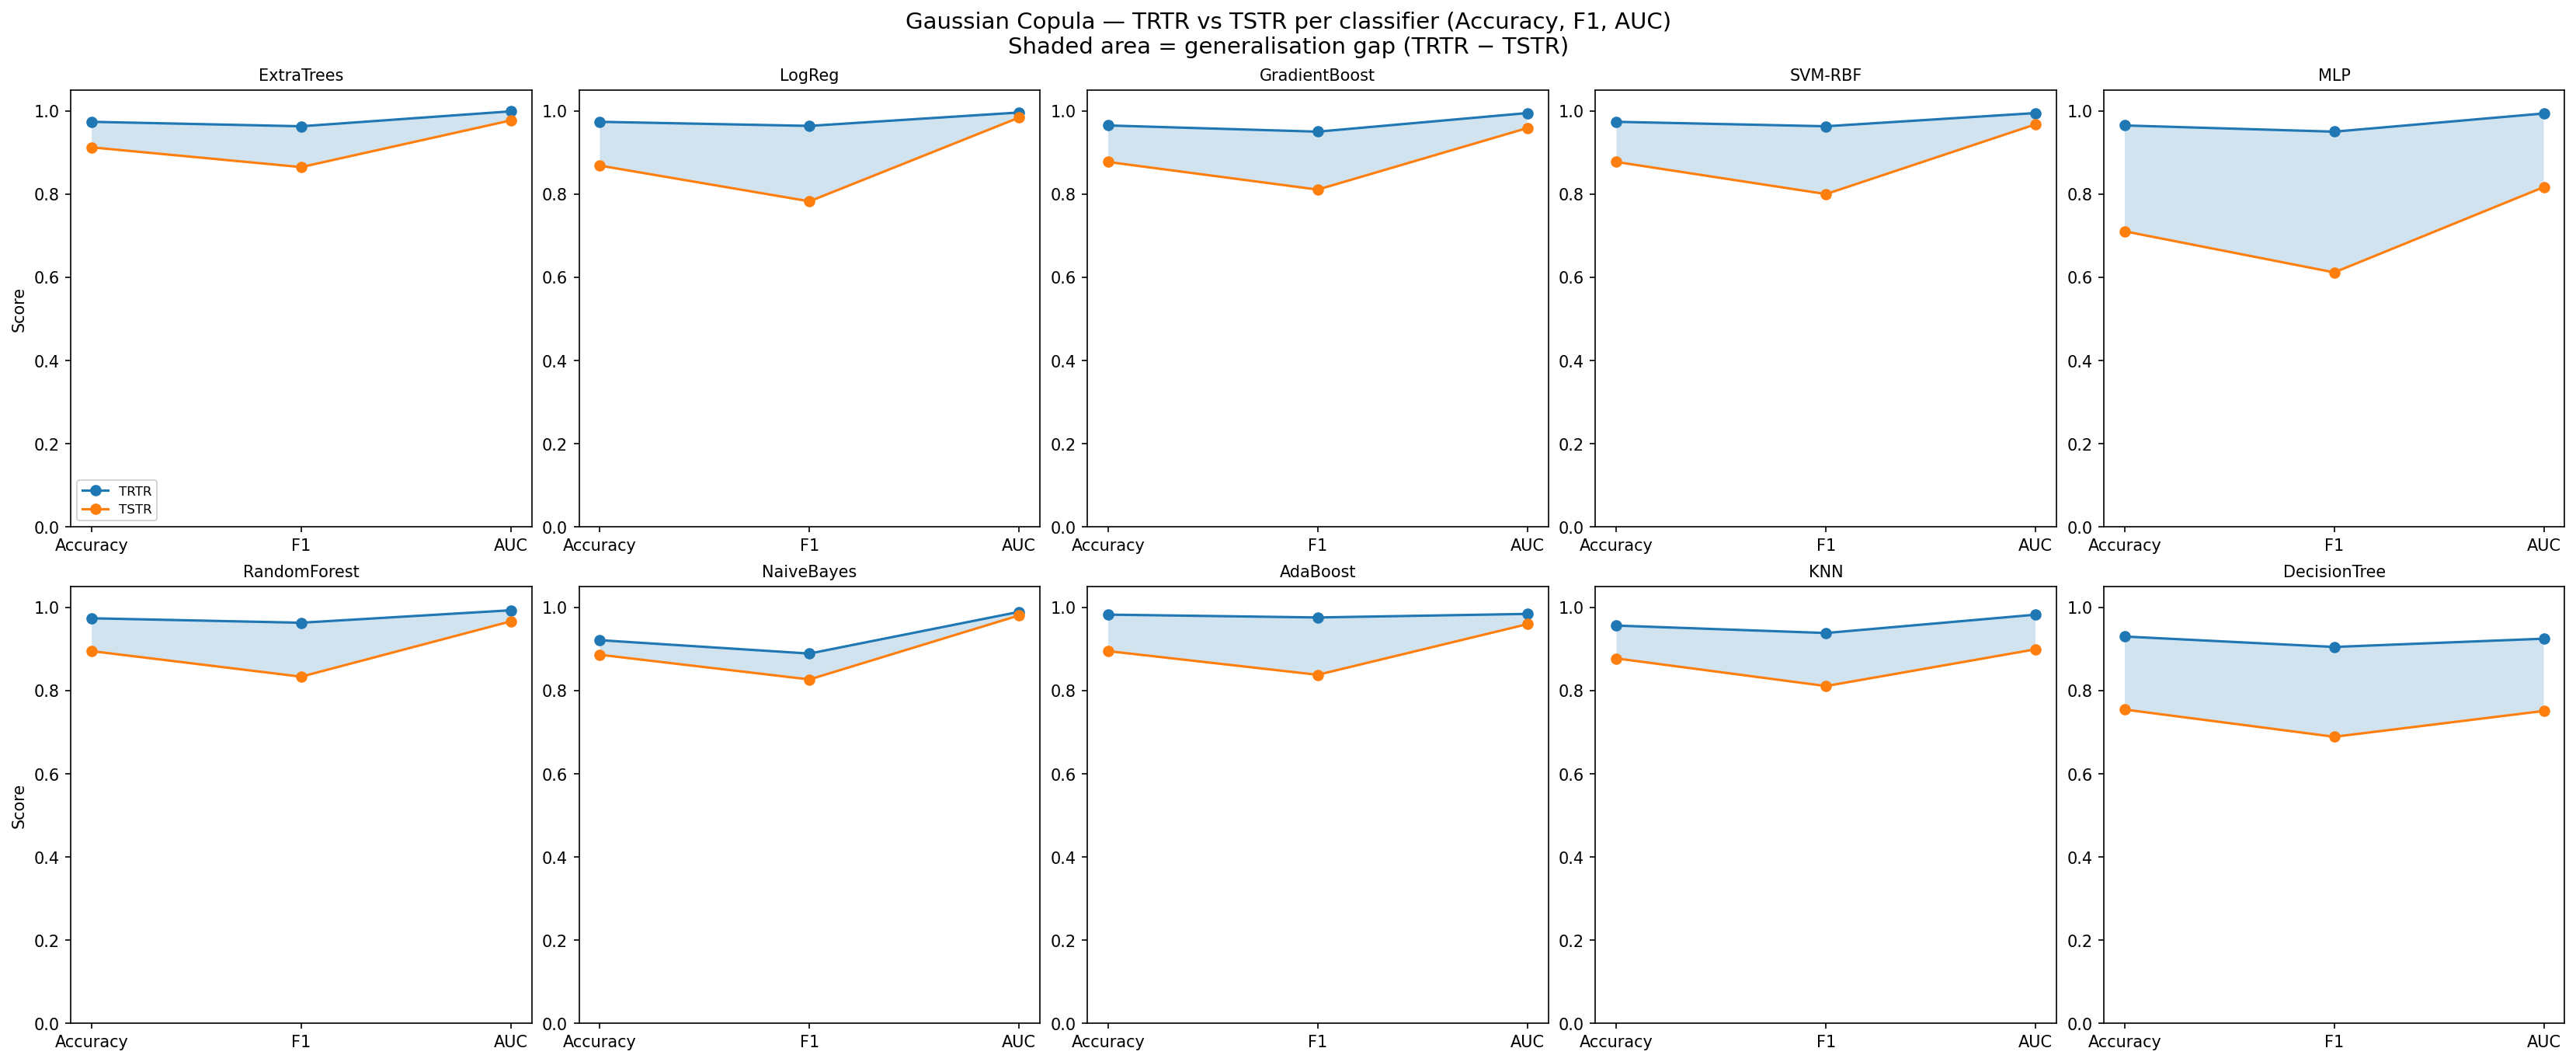

In [ ]:
plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results_gc,
    generator_name="Gaussian Copula",
    ncols=5
)

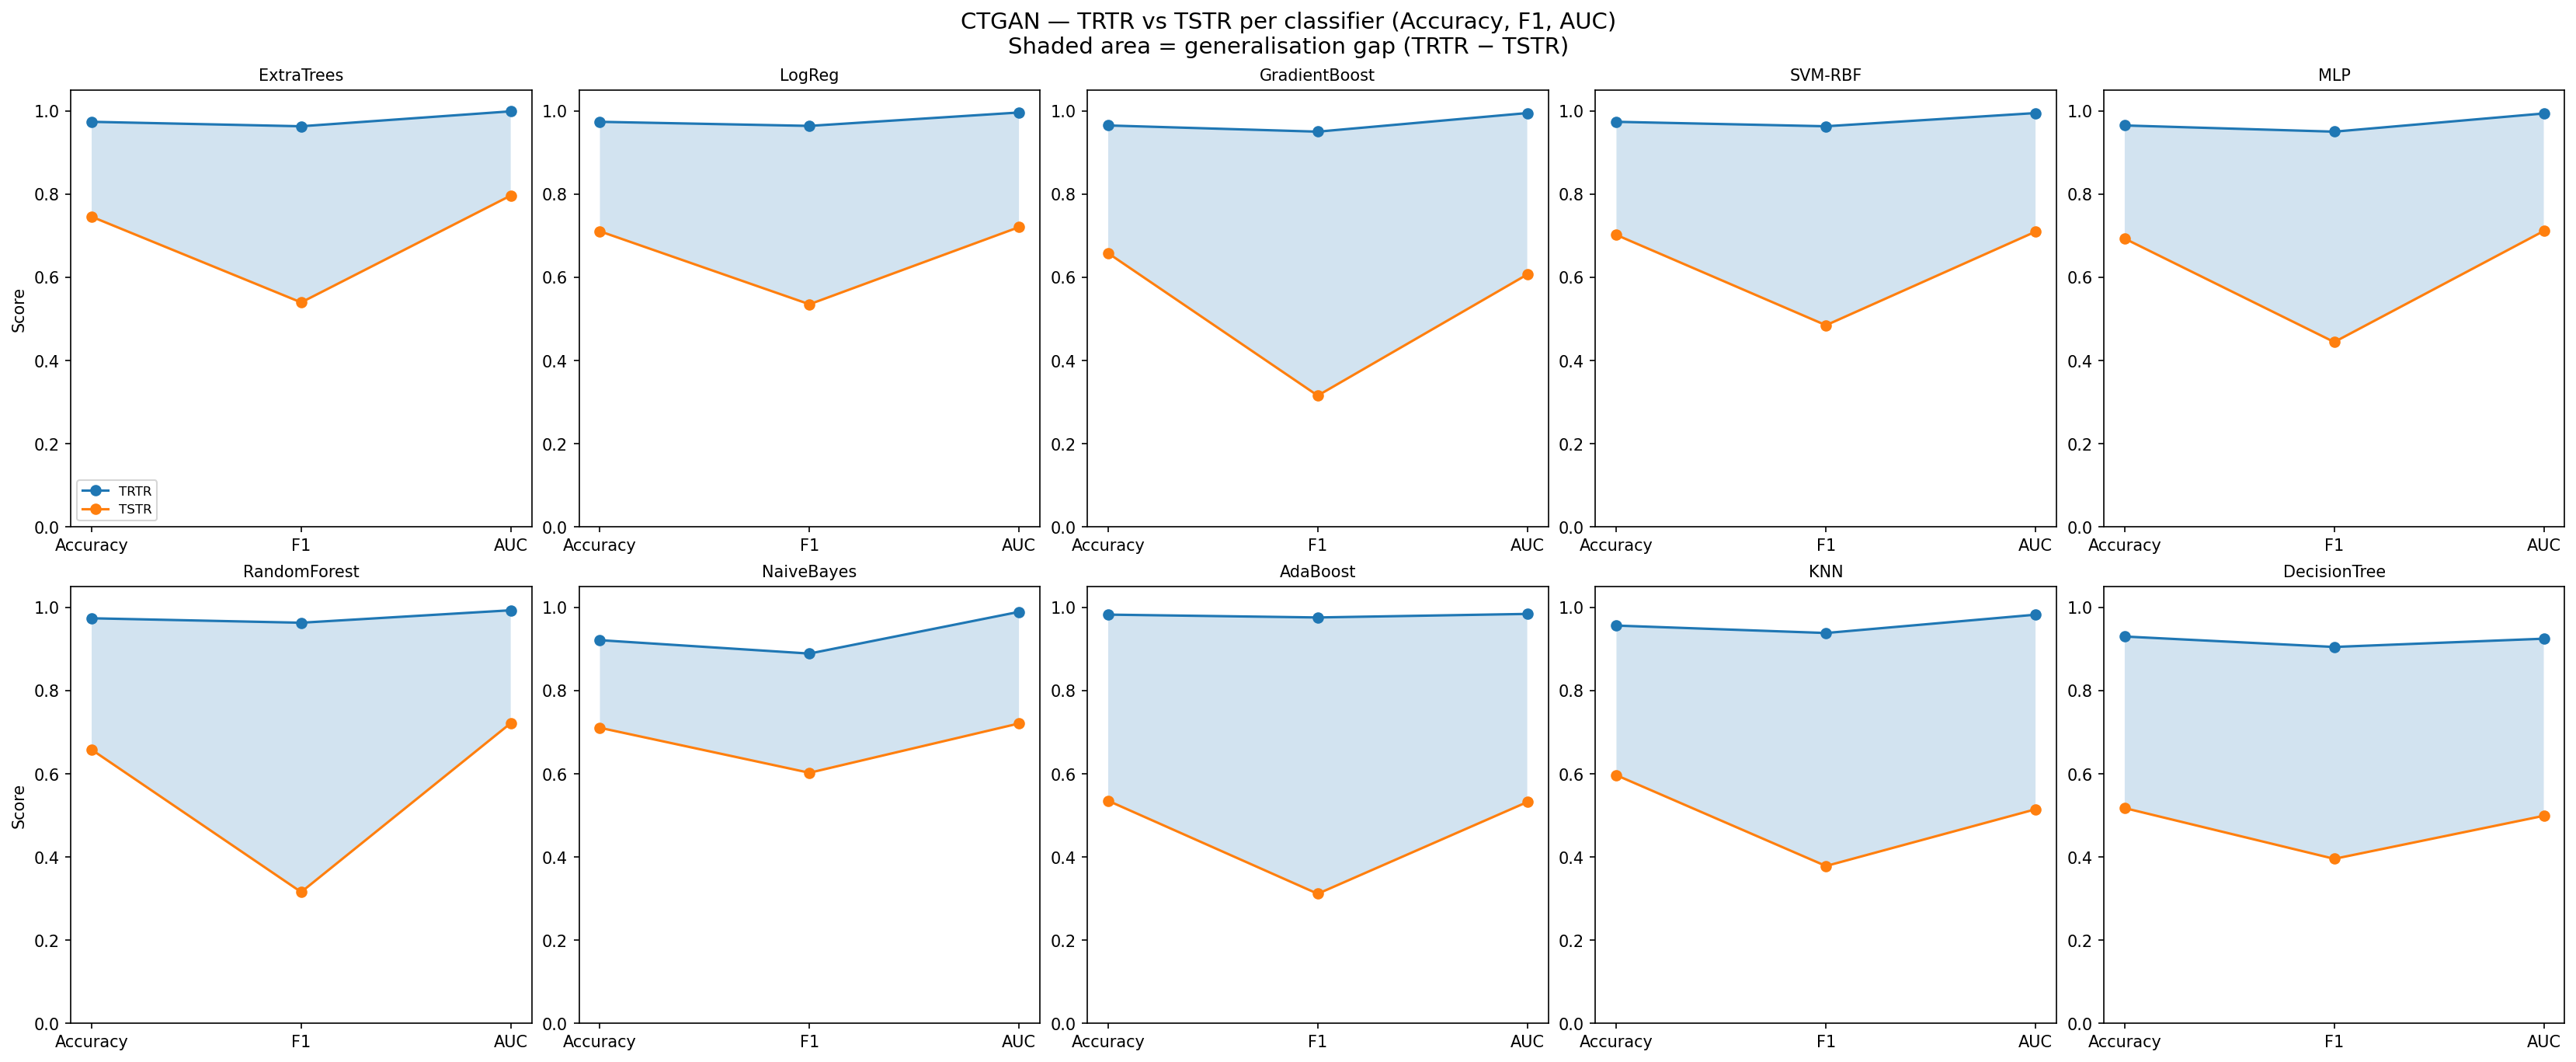

In [ ]:
plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results_ctgan,
    generator_name="CTGAN",
    ncols=5
)

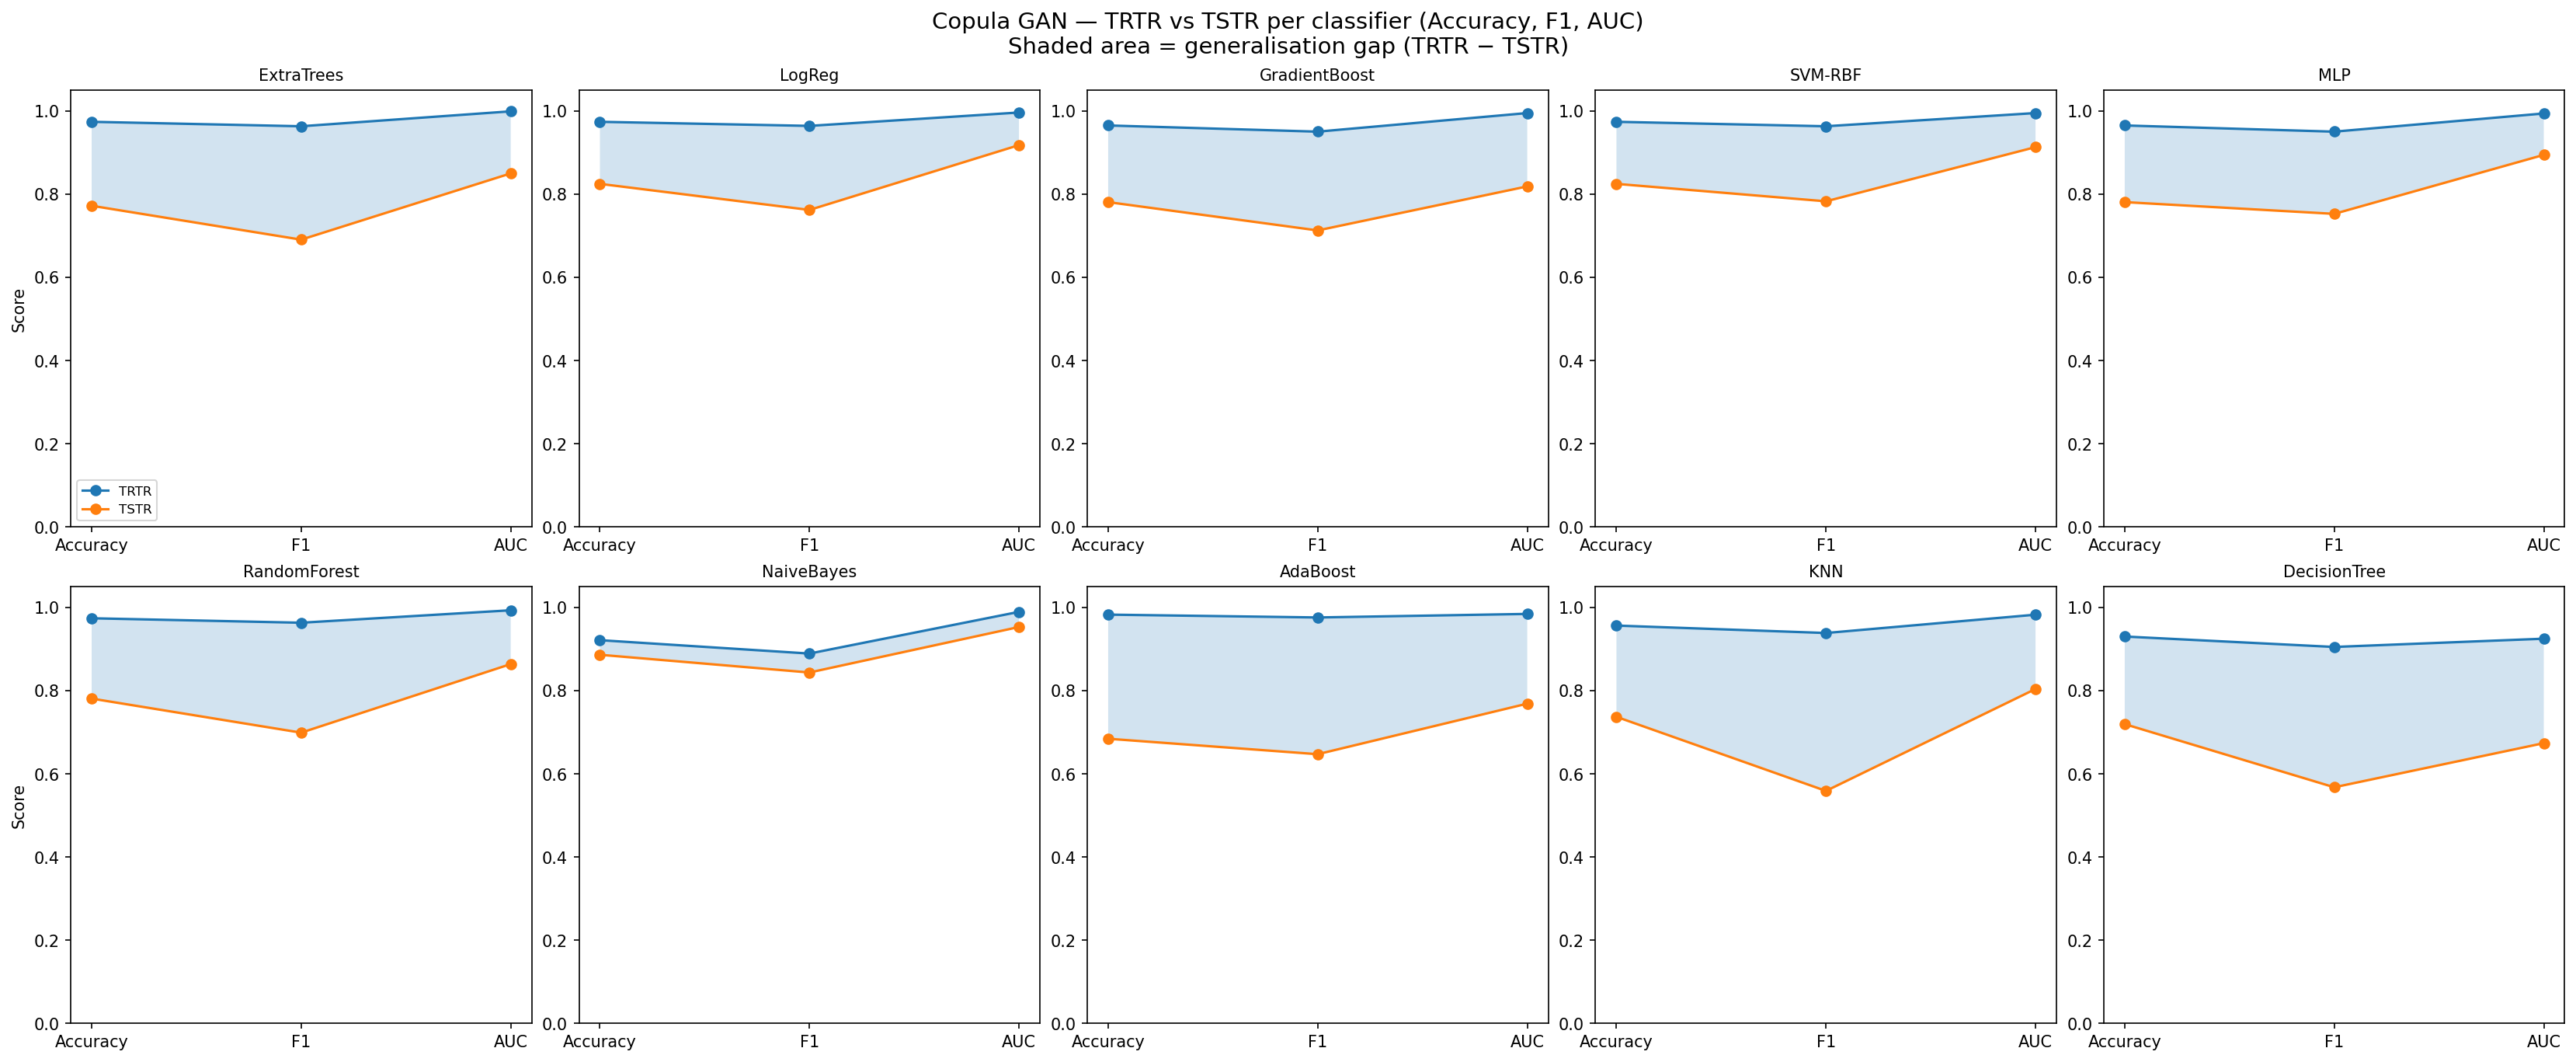

In [ ]:
plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results_copulagan,
    generator_name="Copula GAN",
    ncols=5
)

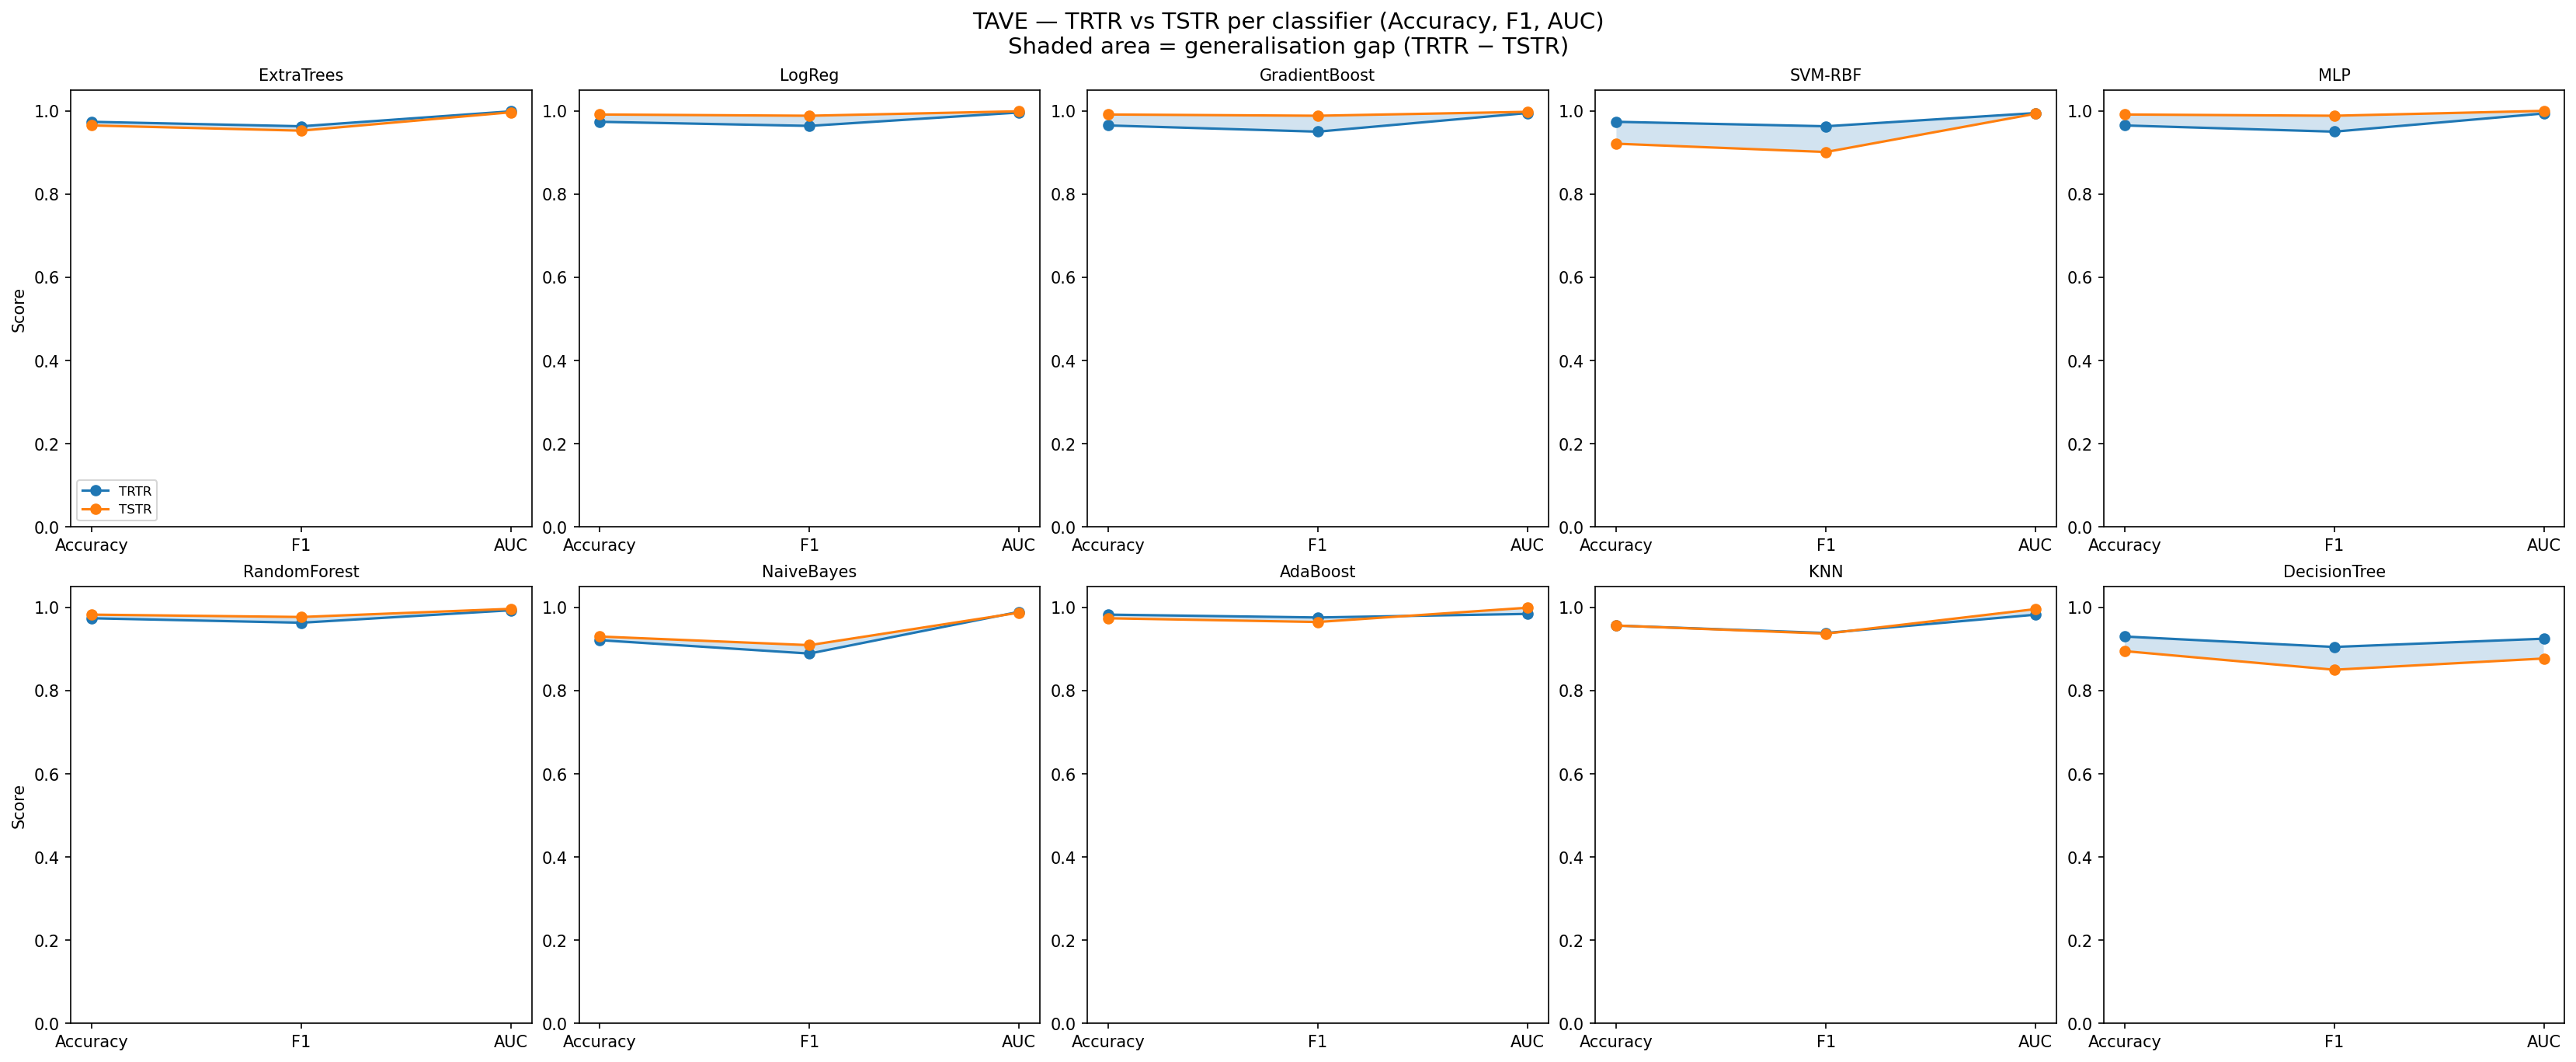

In [ ]:
plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results_tvae,
    generator_name="TAVE",
    ncols=5
)